<div align="center">

# 03 — Analisis Komparatif Arsitektur Deep Learning untuk Deteksi Kerusakan Jalan

Notebook ini menjalankan studi komparatif lima arsitektur deteksi objek berbasis YOLO pada dataset N-RDD2024 subset Asia 6 kelas: **YOLOv8n**, **YOLOv12n**, **YOLOv26n**, **YOLOv8-PD** (rekonstruksi dari Zeng & Zhong, 2024), dan **YOLO-RD** (rekonstruksi dari Wang et al., 2025). Semua model dilatih dengan **Focal Loss** (subclass `v8DetectionLoss`) dan bobot COCO pretrained. Training dijalankan dalam satu loop; tinggal aktifkan atau nonaktifkan entri di `MODELS` sesuai kebutuhan.

</div>

In [1]:
# # Jalankan sekali jika environment belum lengkap.
# # Setelah install selesai, restart kernel agar import library bersih.
# from pathlib import Path

# requirements_file = Path("requirements_yolov8_local.txt")
# if not requirements_file.exists():
#     requirements_file = Path("code/requirements_yolov8_local.txt")

# %pip install -U -r {requirements_file}

# # PENTING: torch/torchvision TIDAK di requirements (agar tidak menarik build CPU dari PyPI).
# # Jika CUDA tidak terdeteksi setelah install, pasang build CUDA secara terpisah:
# #   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
# # lalu restart kernel.
# import torch
# print(f"\ntorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
# if not torch.cuda.is_available():
#     print("CUDA TIDAK tersedia. Install torch CUDA dari index PyTorch (lihat komentar di atas), lalu restart kernel.")

In [2]:
import torch
print(f"torch version     : {torch.__version__}")
print(f"torch cuda build  : {torch.version.cuda}")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU       : {torch.cuda.get_device_name(0)}")
else:
    print("CUDA tidak tersedia — training akan sangat lambat / gagal untuk 300 epoch.")

torch version     : 2.5.1+cu121
torch cuda build  : 12.1
CUDA available    : True
Current GPU       : NVIDIA GeForce RTX 4070 SUPER


## ***Konfigurasi Global***

---

Satu cell ini berisi seluruh konstanta eksperimen. Ubah di sini, bukan di cell lain.

In [3]:
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

# ── Smoke test flag ──────────────────────────────────────────────────────────
# True  → 5 epoch, cepat untuk verifikasi pipeline
# False → 300 epoch, eksperimen final
SMOKE_TEST = False

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT_CANDIDATES = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path("D:/01_Akademik/TA-Project"),
]
REPO_ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "data").exists()),
    Path.cwd().resolve(),
)
DATASET_DIR = (
    REPO_ROOT
    / "data/NRDD-2024/RDD_Split_Final_china_japan_india_6_classes"
    / "RDD_Split_Final_china_japan_india_6_classes"
)
OUTPUT_DIR = REPO_ROOT / "runs/rdd_yolov8n_local"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS      = 2 if SMOKE_TEST else 300
PATIENCE    = 10 if SMOKE_TEST else 40
IMGSZ       = 640

# ── Focal loss ───────────────────────────────────────────────────────────────
FOCAL_GAMMA = 1.5

# ── Augmentasi ───────────────────────────────────────────────────────────────
MOSAIC       = 1.0
MIXUP        = 0.05
FLIPLR       = 0.5
TRANSLATE    = 0.10
SCALE        = 0.50
DEGREES      = 0.0   # Tidak menggunakan rotasi (arahan metodologi/dospem)
CLOSE_MOSAIC = 10

# ── Evaluasi ─────────────────────────────────────────────────────────────────
EVAL_CONF    = 0.001
EVAL_IOU     = 0.60
PRED_CONF    = 0.25
PRED_IOU     = 0.60

# ── Kelas dataset ────────────────────────────────────────────────────────────
CLASS_NAMES = [
    "Longitudinal_Crack",
    "Transverse_Crack",
    "Alligator_Crack",
    "Pothole",
    "manhole",
    "patchy_road",
]

# ── Daftar model ─────────────────────────────────────────────────────────────
# kind:
#   "pretrained"  → spec adalah nama file .pt di code/ (atau nama yg di-download Ultralytics)
#   "yaml_custom" → spec adalah path yaml relatif terhadap REPO_ROOT
# batch: override batch per model (untuk YAML custom lebih kecil karena modul baru)
# amp:   False untuk yaml_custom (modul belum diverifikasi aman di mixed-precision)
MODELS = [
    {"name": "yolov8n_class_weight",     "spec": "yolov8n.pt",               "kind": "pretrained",  "batch": 32, "amp": True},
    # {"name": "yolov12n_focal",  "spec": "yolo12n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov26n_focal",  "spec": "yolo26n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov8_pd_focal", "spec": "code/models/yolov8-pd.yaml", "kind": "yaml_custom", "batch": 16, "amp": False},
    # {"name": "yolo_rd_focal",   "spec": "code/models/yolo-rd.yaml",   "kind": "yaml_custom", "batch": 8,  "amp": False},
]

# ── Verifikasi path ──────────────────────────────────────────────────────────
print(f"Repo root   : {REPO_ROOT}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Smoke test  : {SMOKE_TEST}  →  epochs={EPOCHS}, patience={PATIENCE}")
assert DATASET_DIR.exists(), f"Dataset tidak ditemukan: {DATASET_DIR}"

Repo root   : D:\Faaris\Project-TA\road-damage-detection-ta
Dataset dir : D:\Faaris\Project-TA\road-damage-detection-ta\data\NRDD-2024\RDD_Split_Final_china_japan_india_6_classes\RDD_Split_Final_china_japan_india_6_classes
Output dir  : D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local
Smoke test  : False  →  epochs=300, patience=40


## ***Imports dan Setup Awal***

---

In [4]:
import json
import os
import random
import sys
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import Image, display

# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU / CPU
print(f"Torch version       : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count   : {torch.cuda.device_count()}")
    print(f"Current GPU         : {torch.cuda.get_device_name(0)}")
    DEVICE = 0
    BATCH  = 16   # default; tiap model bisa override via MODELS[i]["batch"]
else:
    print("Training akan berjalan di CPU. Untuk 300 epoch, sangat disarankan memakai GPU.")
    DEVICE = "cpu"
    BATCH  = 4

# Windows notebook lebih stabil dengan workers=0
WORKERS = 0 if os.name == "nt" else 4
print(f"Device untuk YOLO   : {DEVICE}")
print(f"Batch default       : {BATCH}")
print(f"Dataloader workers  : {WORKERS}")

Torch version       : 2.5.1+cu121
CUDA available      : True
CUDA device count   : 1
Current GPU         : NVIDIA GeForce RTX 4070 SUPER
Device untuk YOLO   : 0
Batch default       : 16
Dataloader workers  : 0


## ***Persiapan YAML Lokal***

---

File YAML bawaan dataset memakai `path: .`. Cell ini membuat YAML turunan dengan path absolut dan nama kelas yang konsisten agar notebook berjalan dari direktori mana pun.

In [5]:
original_yaml = DATASET_DIR / "data.yaml"
with original_yaml.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"]  = str(DATASET_DIR.resolve()).replace("\\", "/")
data_cfg["train"] = "train/images"
data_cfg["val"]   = "val/images"
data_cfg["test"]  = "test/images"
data_cfg["nc"]    = len(CLASS_NAMES)
data_cfg["names"] = CLASS_NAMES

local_yaml = OUTPUT_DIR / "rdd6_local.yaml"
with local_yaml.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False, allow_unicode=False)

print(local_yaml)
print(local_yaml.read_text(encoding="utf-8"))

D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local\rdd6_local.yaml
path: D:/Faaris/Project-TA/road-damage-detection-ta/data/NRDD-2024/RDD_Split_Final_china_japan_india_6_classes/RDD_Split_Final_china_japan_india_6_classes
train: train/images
val: val/images
test: test/images
nc: 6
names:
- Longitudinal_Crack
- Transverse_Crack
- Alligator_Crack
- Pothole
- manhole
- patchy_road



## ***Audit Dataset***

---

Audit jumlah gambar, label, objek, missing label, dan extra label sebelum training. File `classes.txt` di folder labels diabaikan.

In [6]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def list_images(split: str):
    image_dir = DATASET_DIR / split / "images"
    return sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMG_EXTS])


def list_label_files(split: str):
    label_dir = DATASET_DIR / split / "labels"
    return sorted([p for p in label_dir.glob("*.txt") if p.name.lower() != "classes.txt"])


def read_yolo_labels(label_path):
    rows = []
    for line_no, line in enumerate(
        label_path.read_text(encoding="utf-8", errors="ignore").splitlines(), start=1
    ):
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) != 5:
            rows.append({"file": label_path.name, "line": line_no, "error": "not_5_columns", "raw": line})
            continue
        cls, x, y, w, h = parts
        try:
            rows.append({
                "file": label_path.name,
                "class_id": int(float(cls)),
                "x": float(x), "y": float(y), "w": float(w), "h": float(h),
            })
        except ValueError:
            rows.append({"file": label_path.name, "line": line_no, "error": "parse_error", "raw": line})
    return rows


summary_rows, label_rows, invalid_rows = [], [], []

for split in ["train", "val", "test"]:
    images = list_images(split)
    labels = list_label_files(split)
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    split_counter = Counter()
    split_objects = 0
    for label_path in labels:
        for row in read_yolo_labels(label_path):
            if "error" in row:
                invalid_rows.append({"split": split, **row})
                continue
            class_id = row["class_id"]
            if class_id < 0 or class_id >= len(CLASS_NAMES):
                invalid_rows.append({"split": split, "file": row["file"], "error": "class_id_out_of_range", "class_id": class_id})
                continue
            if not all(0.0 <= row[k] <= 1.0 for k in ["x", "y", "w", "h"]):
                invalid_rows.append({"split": split, "file": row["file"], "error": "bbox_out_of_0_1_range", **row})
                continue
            split_counter[class_id] += 1
            split_objects += 1
            label_rows.append({"split": split, "class_id": class_id, "class_name": CLASS_NAMES[class_id], **row})

    summary_rows.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "objects": split_objects,
        "missing_label_files": len(image_stems - label_stems),
        "extra_label_files": len(label_stems - image_stems),
    })

summary_df  = pd.DataFrame(summary_rows)
labels_df   = pd.DataFrame(label_rows)
invalid_df  = pd.DataFrame(invalid_rows)

class_df = (
    labels_df.groupby(["split", "class_id", "class_name"])
    .size().rename("objects").reset_index()
)
class_pivot = class_df.pivot_table(
    index=["class_id", "class_name"], columns="split", values="objects", fill_value=0
).reset_index()
for col in ["train", "val", "test"]:
    if col not in class_pivot.columns:
        class_pivot[col] = 0
class_pivot["total"]   = class_pivot[["train", "val", "test"]].sum(axis=1)
class_pivot["percent"] = class_pivot["total"] / class_pivot["total"].sum() * 100

print("Summary split:")
display(summary_df)
print("Distribusi kelas:")
display(class_pivot[["class_id", "class_name", "train", "val", "test", "total", "percent"]])

assert invalid_df.empty, f"Ada label invalid, cek invalid_df: {invalid_df.head()}"
assert (summary_df["missing_label_files"] == 0).all(), "Ada gambar tanpa label."
assert (summary_df["extra_label_files"] == 0).all(), "Ada label tanpa gambar."

class_pivot.to_csv(OUTPUT_DIR / "dataset_class_distribution.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "dataset_split_summary.csv", index=False)

Summary split:


,split,images,labels,objects,missing_label_files,extra_label_files
0,train,6777,6777,17092,0,0
1,val,1898,1898,4773,0,0
2,test,995,995,2425,0,0


Distribusi kelas:


split,class_id,class_name,train,val,test,total,percent
0,0,Longitudinal_Crack,4555.0,1257.0,635.0,6447.0,26.541787
1,1,Transverse_Crack,3219.0,897.0,446.0,4562.0,18.781392
2,2,Alligator_Crack,4385.0,1245.0,642.0,6272.0,25.821326
3,3,Pothole,2192.0,597.0,312.0,3101.0,12.766571
4,4,manhole,2270.0,645.0,321.0,3236.0,13.322355
5,5,patchy_road,471.0,132.0,69.0,672.0,2.766571


### ***Visualisasi Distribusi Kelas***

C:\Users\User\AppData\Local\Temp\ipykernel_20932\171794449.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(class_pivot["class_name"], rotation=25, ha="right")


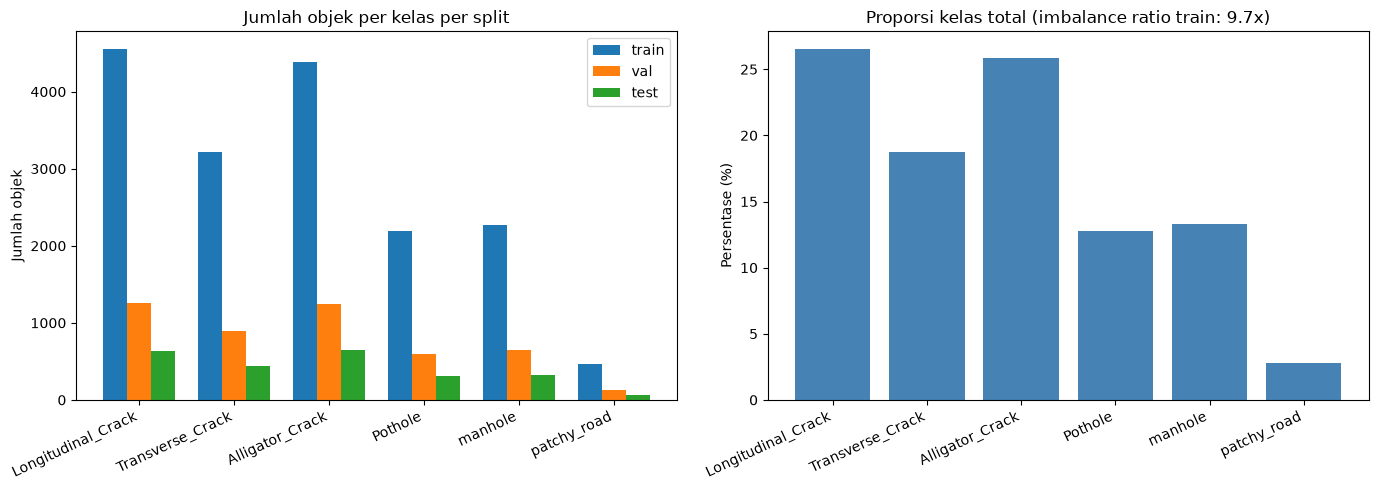

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

splits_plot = ["train", "val", "test"]
x = np.arange(len(CLASS_NAMES))
width = 0.25
for i, split in enumerate(splits_plot):
    axes[0].bar(x + i * width, class_pivot[split], width, label=split)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(class_pivot["class_name"], rotation=25, ha="right")
axes[0].set_title("Jumlah objek per kelas per split")
axes[0].set_ylabel("Jumlah objek")
axes[0].legend()

max_count = class_pivot["train"].max()
min_count = class_pivot["train"].replace(0, np.nan).min()
imbalance_ratio = max_count / min_count if min_count and min_count > 0 else float("nan")
axes[1].bar(class_pivot["class_name"], class_pivot["percent"], color="steelblue")
axes[1].set_xticklabels(class_pivot["class_name"], rotation=25, ha="right")
axes[1].set_title(f"Proporsi kelas total (imbalance ratio train: {imbalance_ratio:.1f}x)")
axes[1].set_ylabel("Persentase (%)")

plt.tight_layout()
plt.show()

### ***Visualisasi Sampel Label***

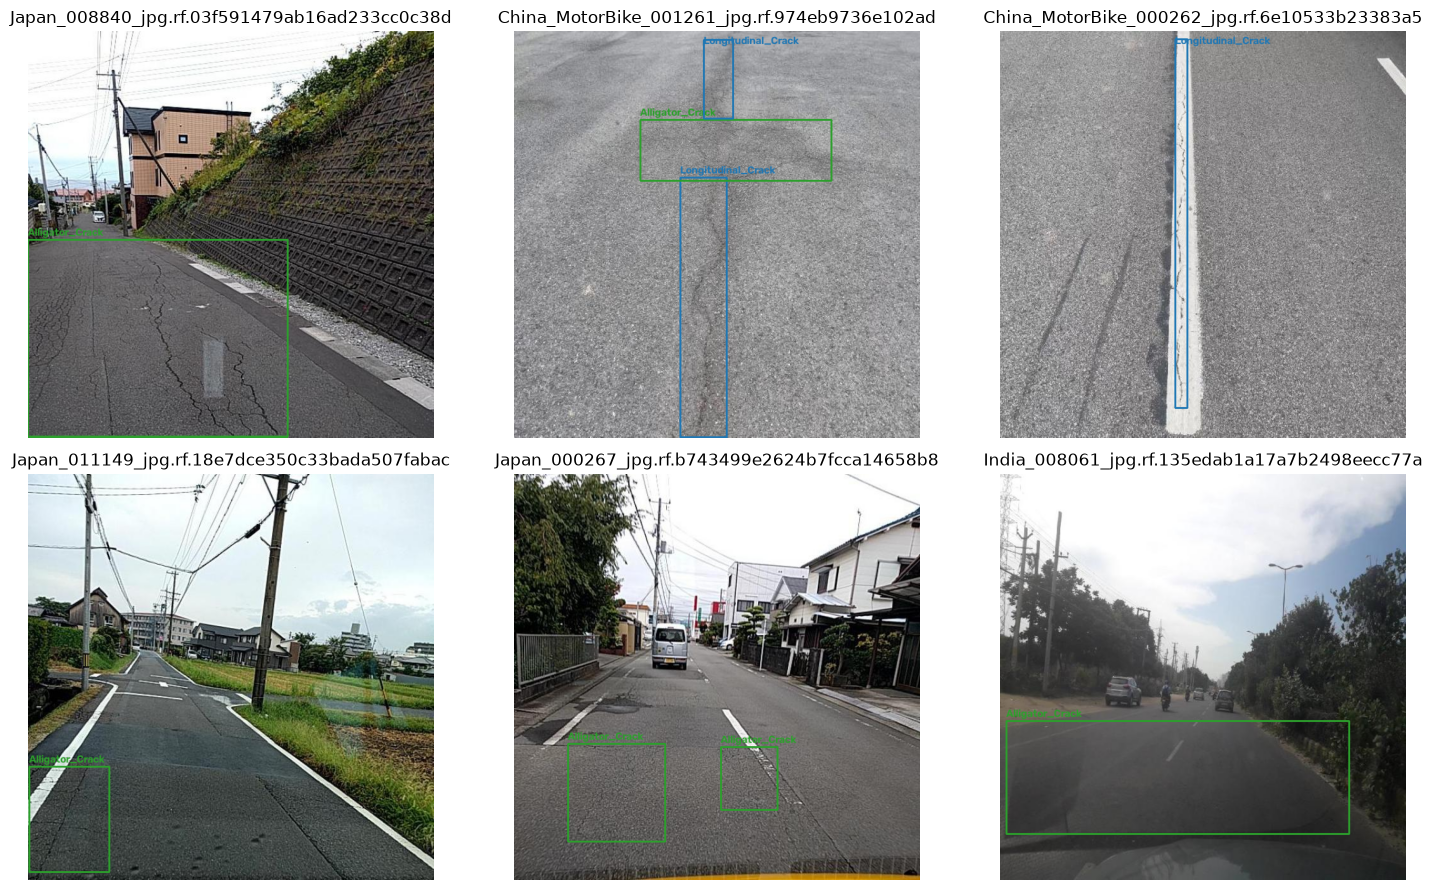

In [8]:
def draw_yolo_boxes(image_path, label_path):
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h_img, w_img = image.shape[:2]
    if not label_path.exists():
        return image
    for row in read_yolo_labels(label_path):
        if "error" in row:
            continue
        cls = int(row["class_id"])
        x, y, w, h = row["x"], row["y"], row["w"], row["h"]
        x1 = int((x - w / 2) * w_img)
        y1 = int((y - h / 2) * h_img)
        x2 = int((x + w / 2) * w_img)
        y2 = int((y + h / 2) * h_img)
        color = tuple(int(c * 255) for c in sns.color_palette("tab10", len(CLASS_NAMES))[cls])
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, CLASS_NAMES[cls], (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return image


sample_images = random.sample(list_images("train"), k=min(6, len(list_images("train"))))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, image_path in zip(axes, sample_images):
    label_path = DATASET_DIR / "train/labels" / f"{image_path.stem}.txt"
    ax.imshow(draw_yolo_boxes(image_path, label_path))
    ax.set_title(image_path.name[:45])
    ax.axis("off")
for ax in axes[len(sample_images):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## ***Training (Loop)***

---

Loop melakukan iterasi pada `MODELS`. Setiap model:
1. Disiapkan dengan Focal Loss (subclass `v8DetectionLoss`, ganti `self.bce` menjadi `FocalLoss`).
2. Untuk `kind == "yaml_custom"`: load arsitektur dari YAML, lalu transfer bobot COCO via `.load("yolov8n.pt")`.
3. Untuk `kind == "pretrained"`: `YOLO(spec)` biasa.
4. Output tersimpan di `runs/rdd_yolov8n_local/experiments/<run_name>/`.

In [9]:
CUSTOM_DIR = REPO_ROOT / "code/models"

HAS_CUSTOM = any(m["kind"] == "yaml_custom" for m in MODELS)
if HAS_CUSTOM:
    sys.path.insert(0, str(CUSTOM_DIR))
    from custom_modules import patch_ultralytics
    patch_ultralytics()
    print("patch_ultralytics() dipanggil — modul custom terdaftar.")


import gc
import yaml
import numpy as np
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
from ultralytics.utils.loss import v8DetectionLoss
from ultralytics.nn.tasks import DetectionModel


def count_class_instances(data_yaml_path, split="train"):
    """Scan file label YOLO-format (.txt) pada split tertentu, hitung jumlah
    instance per kelas (list sepanjang nc, terurut sesuai data.yaml)."""
    data_yaml_path = Path(data_yaml_path)
    with open(data_yaml_path) as f:
        cfg = yaml.safe_load(f)
    base = Path(cfg.get("path", data_yaml_path.parent))
    if not base.is_absolute():
        base = data_yaml_path.parent / base
    split_val = cfg[split]
    img_dirs = [split_val] if isinstance(split_val, str) else list(split_val)
    nc = cfg["nc"]
    counts = Counter({i: 0 for i in range(nc)})
    for img_dir in img_dirs:
        label_dir_path = Path(str(base / img_dir).replace("images", "labels"))
        for txt_file in label_dir_path.rglob("*.txt"):
            if txt_file.name.lower() == "classes.txt":
                continue
            with open(txt_file) as f:
                for line in f:
                    line = line.strip()
                    if line:
                        counts[int(line.split()[0])] += 1
    return [counts[i] for i in range(nc)]


def effective_number_weights(counts, beta=0.999):
    """Class-Balanced weighting via Effective Number of Samples.
    Cui, Y., Jia, M., Lin, T-Y., Song, Y., & Belongie, S. (2019).
    "Class-Balanced Loss Based on Effective Number of Samples." CVPR 2019.
    https://arxiv.org/abs/1901.05555
    """
    counts_arr = np.clip(np.array(counts, dtype=np.float64), 1, None)
    effective_num = 1.0 - np.power(beta, counts_arr)
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.sum() * len(counts_arr)
    return torch.tensor(weights, dtype=torch.float32)


print("Menghitung distribusi kelas dari dataset training...")
CLASS_COUNTS = count_class_instances(local_yaml, split="train")
CLASS_WEIGHTS = effective_number_weights(CLASS_COUNTS, beta=0.999)
print(f"Jumlah per kelas : {CLASS_COUNTS}")
print(f"Class weights    : {[round(w, 3) for w in CLASS_WEIGHTS.tolist()]}")


def _init_criterion_with_class_weights(self):
    """Patch di level CLASS DetectionModel (bukan instance) -- ini WAJIB,
    karena Ultralytics Trainer membangun ulang objek model dari nol di dalam
    `.train()`, sehingga patch instance-level (mis. `model.model.init_criterion = ...`
    sebelum `.train()`) tidak akan berpengaruh. Berlaku otomatis untuk semua
    model (YOLOv8n, YOLOv8-PD, YOLO-RD -- semua subclass DetectionModel)."""
    if getattr(self, "class_weights", None) is None:
        self.class_weights = CLASS_WEIGHTS.to(next(self.parameters()).device)
    return v8DetectionLoss(self)

DetectionModel.init_criterion = _init_criterion_with_class_weights

# Verifikasi class_weights benar-benar aktif
_dummy = YOLO("yolov8n.pt")
_dummy.model.train()
_crit = _dummy.model.init_criterion()
assert torch.allclose(_crit.class_weights.cpu(), CLASS_WEIGHTS), "class_weights tidak aktif!"
print(f"Class-balanced weighting terverifikasi aktif (beta=0.999, sumber: Cui et al. CVPR 2019)")
del _dummy, _crit

Menghitung distribusi kelas dari dataset training...
Jumlah per kelas : [4555, 3219, 4385, 2192, 2270, 471]
Class weights    : [0.761, 0.784, 0.763, 0.848, 0.84, 2.004]
Class-balanced weighting terverifikasi aktif (beta=0.999, sumber: Cui et al. CVPR 2019)


In [26]:
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    mem_free = torch.cuda.mem_get_info()[0] / 1024**3
    print(f"  GPU VRAM bebas setelah cleanup: {mem_free:.2f} GB")

NameError: name 'model' is not defined

In [10]:
MODELS = [
    {"name": "yolov8n_class_weight",     "spec": "yolov8n.pt",               "kind": "pretrained",  "batch": 32, "amp": True},
    {"name": "yolov12n_class_weight",  "spec": "yolo12n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov26n_focal",  "spec": "yolo26n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov8_pd_focal", "spec": "code/models/yolov8-pd.yaml", "kind": "yaml_custom", "batch": 16, "amp": False},
    # {"name": "yolo_rd_focal",   "spec": "code/models/yolo-rd.yaml",   "kind": "yaml_custom", "batch": 8,  "amp": False},
]

In [11]:
PROJECT_DIR = OUTPUT_DIR / "experiments"
trained_runs = []  # daftar (model_name, run_name) untuk cell evaluasi

for m in MODELS:
    run_name = f"{m['name']}_smoke" if SMOKE_TEST else m["name"]
    print(f"\n{'='*60}")
    print(f"Training: {run_name}")
    print(f"{'='*60}")

    if m["kind"] == "yaml_custom":
        spec_path = REPO_ROOT / m["spec"]
        model = YOLO(str(spec_path), task="detect")
        model.load(str(REPO_ROOT / "code/yolov8n.pt"))
    else:
        # pretrained: coba resolve dari code/ dulu, fallback ke auto-download
        spec_path_local = REPO_ROOT / "code" / m["spec"]
        spec = str(spec_path_local) if spec_path_local.exists() else m["spec"]
        model = YOLO(spec)

    # (Tidak perlu lagi baris `model.model.init_criterion = ...` per-model --
    # sudah ditangani otomatis & konsisten oleh patch class di atas.)

    batch_size = m.get("batch", BATCH)
    amp_flag   = m.get("amp", True)

    model.train(
        data=str(local_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=16, 
        device=DEVICE,
        workers=WORKERS,
        project=str(PROJECT_DIR),
        name=run_name,
        exist_ok=True,
        seed=SEED,
        deterministic=True,
        optimizer="auto",
        patience=PATIENCE,
        cache=False,
        amp=amp_flag,
        cos_lr=True,
        plots=True,
        save=True,
        save_period=25,
        close_mosaic=CLOSE_MOSAIC,
        mosaic=MOSAIC,
        mixup=MIXUP,
        fliplr=FLIPLR,
        translate=TRANSLATE,
        scale=SCALE,
        degrees=DEGREES,
    )

    trained_runs.append((m["name"], run_name))
    print(f"Selesai: {run_name}")

    # Bebaskan VRAM sebelum model berikutnya
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        mem_free = torch.cuda.mem_get_info()[0] / 1024**3
        print(f"  GPU VRAM bebas setelah cleanup: {mem_free:.2f} GB")

print("\nSemua model selesai ditraining:", trained_runs)


Training: yolov8n_class_weight
New https://pypi.org/project/ultralytics/8.4.114 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.108  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local\rdd6_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kera

In [ ]:
# CUSTOM_DIR = REPO_ROOT / "code/models"

# HAS_CUSTOM = any(m["kind"] == "yaml_custom" for m in MODELS)
# if HAS_CUSTOM:
#     sys.path.insert(0, str(CUSTOM_DIR))
#     from custom_modules import patch_ultralytics
#     patch_ultralytics()
#     print("patch_ultralytics() dipanggil — modul custom terdaftar.")


# import gc
# from ultralytics import YOLO
# from ultralytics.utils.loss import FocalLoss, v8DetectionLoss


# class FocalDetectionLoss(v8DetectionLoss):
#     """v8DetectionLoss dengan self.bce diganti FocalLoss.

#     Ultralytics >= 8.4.108 selalu memakai BCE di v8DetectionLoss.
#     fl_gamma bukan parameter publik yang stabil, sehingga subclass ini
#     adalah satu-satunya cara yang terverifikasi untuk mengaktifkan Focal Loss
#     di YOLOv8n, YOLOv8-PD, maupun YOLO-RD.
#     """

#     def __init__(self, model, tal_topk=10):
#         super().__init__(model, tal_topk=tal_topk)
#         self.bce = FocalLoss(gamma=FOCAL_GAMMA)


# # Verifikasi FocalDetectionLoss aktif
# _dummy = YOLO("yolov8n.pt")
# _loss  = FocalDetectionLoss(_dummy.model)
# assert isinstance(_loss.bce, FocalLoss), "FocalLoss tidak aktif!"
# print(f"Focal Loss terverifikasi aktif  (gamma={FOCAL_GAMMA}, bce={type(_loss.bce).__name__})")
# del _dummy, _loss

# PROJECT_DIR = OUTPUT_DIR / "experiments"
# trained_runs = []  # daftar (model_name, run_name) untuk cell evaluasi

# for m in MODELS:
#     run_name = f"{m['name']}_smoke" if SMOKE_TEST else m["name"]
#     print(f"\n{'='*60}")
#     print(f"Training: {run_name}")
#     print(f"{'='*60}")

#     if m["kind"] == "yaml_custom":
#         spec_path = REPO_ROOT / m["spec"]
#         model = YOLO(str(spec_path), task="detect")
#         model.load(str(REPO_ROOT / "code/yolov8n.pt"))
#     else:
#         # pretrained: coba resolve dari code/ dulu, fallback ke auto-download
#         spec_path_local = REPO_ROOT / "code" / m["spec"]
#         spec = str(spec_path_local) if spec_path_local.exists() else m["spec"]
#         model = YOLO(spec)

#     # Pasang Focal Loss
#     model.model.init_criterion = lambda _m=model.model: FocalDetectionLoss(_m)

#     batch_size = m.get("batch", BATCH)
#     amp_flag   = m.get("amp", True)

#     model.train(
#         data=str(local_yaml),
#         epochs=EPOCHS,
#         imgsz=IMGSZ,
#         batch=batch_size,
#         device=DEVICE,
#         workers=WORKERS,
#         project=str(PROJECT_DIR),
#         name=run_name,
#         exist_ok=True,
#         seed=SEED,
#         deterministic=True,
#         optimizer="auto",
#         patience=PATIENCE,
#         cache=False,
#         amp=amp_flag,
#         cos_lr=True,
#         plots=True,
#         save=True,
#         save_period=25,
#         close_mosaic=CLOSE_MOSAIC,
#         mosaic=MOSAIC,
#         mixup=MIXUP,
#         fliplr=FLIPLR,
#         translate=TRANSLATE,
#         scale=SCALE,
#         degrees=DEGREES,
#     )

#     trained_runs.append((m["name"], run_name))
#     print(f"Selesai: {run_name}")

#     # Bebaskan VRAM sebelum model berikutnya
#     del model
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()
#         mem_free = torch.cuda.mem_get_info()[0] / 1024**3
#         print(f"  GPU VRAM bebas setelah cleanup: {mem_free:.2f} GB")

# print("\nSemua model selesai ditraining:", trained_runs)

## ***Evaluasi per Model***

---

Evaluasi val dan test untuk setiap model. Output disimpan di `runs/rdd_yolov8n_local/evaluation/` dengan prefix nama model.

In [12]:
# Jika modul custom diperlukan saat load best.pt, patch harus sudah aktif
# (dipanggil di cell training). Jika cell ini dijalankan tanpa training terlebih dahulu,
# panggil patch_ultralytics() di sini jika ada yaml_custom di trained_runs.
if HAS_CUSTOM and "patch_ultralytics" not in dir():
    sys.path.insert(0, str(CUSTOM_DIR))
    from custom_modules import patch_ultralytics
    patch_ultralytics()

EVAL_DIR    = OUTPUT_DIR / "evaluation"
eval_results = {}  # model_name → {"val": metrics, "test": metrics}

for model_name, run_name in trained_runs:
    best_weights = PROJECT_DIR / run_name / "weights/best.pt"
    assert best_weights.exists(), f"best.pt tidak ditemukan: {best_weights}"

    best_model = YOLO(str(best_weights))

    print(f"\nEvaluasi {model_name} — val")
    val_metrics = best_model.val(
        data=str(local_yaml),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(EVAL_DIR),
        name=f"{model_name}_val",
        exist_ok=True,
        plots=True,
        save_json=True,
        conf=EVAL_CONF,
        iou=EVAL_IOU,
    )

    print(f"\nEvaluasi {model_name} — test")
    test_metrics = best_model.val(
        data=str(local_yaml),
        split="test",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(EVAL_DIR),
        name=f"{model_name}_test",
        exist_ok=True,
        plots=True,
        save_json=True,
        conf=EVAL_CONF,
        iou=EVAL_IOU,
    )

    eval_results[model_name] = {"val": val_metrics, "test": test_metrics}
    print(f"  val  mAP50: {val_metrics.results_dict.get('metrics/mAP50(B)', float('nan')):.4f}")
    print(f"  test mAP50: {test_metrics.results_dict.get('metrics/mAP50(B)', float('nan')):.4f}")


Evaluasi yolov8n_class_weight — val
Ultralytics 8.4.108  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1088.2282.4 MB/s, size: 79.8 KB)
val: Scanning D:\Faaris\Project-TA\road-damage-detection-ta\data\NRDD-2024\RDD_Split_Final_china_japan_india_6_classes\RDD_Split_Final_china_japan_india_6_classes\val\labels.cache... 1898 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1898/1898  0.0s
val: D:\Faaris\Project-TA\road-damage-detection-ta\data\NRDD-2024\RDD_Split_Final_china_japan_india_6_classes\RDD_Split_Final_china_japan_india_6_classes\val\images\Japan_006916_jpg.rf.6409c53af3c26b4c760f816734ecafc8.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 119/119 8.0it/s 14.9s0.1s
                   all       1898       4772      0.684     

### ***Metrik Per Kelas dan F1 Summary***

In [13]:
def per_class_metrics(metrics, class_names):
    rows = []
    box  = metrics.box
    for class_id, class_name in enumerate(class_names):
        try:
            precision, recall, ap50, ap5095 = box.class_result(class_id)
        except Exception:
            precision, recall, ap50, ap5095 = np.nan, np.nan, np.nan, np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            "class_id":   class_id,
            "class_name": class_name,
            "precision":  float(precision),
            "recall":     float(recall),
            "f1":         float(f1),
            "mAP50":      float(ap50),
            "mAP50-95":   float(ap5095),
        })
    return pd.DataFrame(rows)


def safe_weighted_mean(values, weights):
    values  = np.asarray(values,  dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid   = np.isfinite(values) & np.isfinite(weights)
    if not valid.any() or weights[valid].sum() == 0:
        return float("nan")
    return float(np.average(values[valid], weights=weights[valid]))


for model_name, run_name in trained_runs:
    val_metrics  = eval_results[model_name]["val"]
    test_metrics = eval_results[model_name]["test"]

    val_per_class  = per_class_metrics(val_metrics,  CLASS_NAMES)
    test_per_class = per_class_metrics(test_metrics, CLASS_NAMES)

    val_per_class = val_per_class.merge(
        class_pivot[["class_id", "val"]].rename(columns={"val": "support"}),
        on="class_id", how="left",
    )
    test_per_class = test_per_class.merge(
        class_pivot[["class_id", "test"]].rename(columns={"test": "support"}),
        on="class_id", how="left",
    )

    f1_summary = {
        "val_macro_f1":    float(val_per_class["f1"].mean()),
        "val_weighted_f1": safe_weighted_mean(val_per_class["f1"], val_per_class["support"]),
        "test_macro_f1":   float(test_per_class["f1"].mean()),
        "test_weighted_f1": safe_weighted_mean(test_per_class["f1"], test_per_class["support"]),
    }
    f1_summary_df = pd.DataFrame([f1_summary])

    print(f"\n{'─'*50}")
    print(f"Model: {model_name}")
    print("F1 summary:")
    display(f1_summary_df)
    print("Test per-class metrics:")
    display(test_per_class)

    # Simpan CSV per model
    val_per_class.to_csv(OUTPUT_DIR  / f"{model_name}_val_per_class_metrics.csv",  index=False)
    test_per_class.to_csv(OUTPUT_DIR / f"{model_name}_test_per_class_metrics.csv", index=False)
    f1_summary_df.to_csv(OUTPUT_DIR  / f"{model_name}_f1_summary.csv",             index=False)

    # Simpan summary JSON per model
    speed_total_ms = sum(
        float(v) for k, v in test_metrics.speed.items()
        if k in ["preprocess", "inference", "postprocess"]
    )
    summary = {
        "model":      model_name,
        "run_name":   run_name,
        "weights":    str(PROJECT_DIR / run_name / "weights/best.pt"),
        "data_yaml":  str(local_yaml),
        "imgsz":      IMGSZ,
        "epochs":     EPOCHS,
        "focal_gamma": FOCAL_GAMMA,
        "val_results":  {k: float(v) for k, v in val_metrics.results_dict.items()},
        "test_results": {k: float(v) for k, v in test_metrics.results_dict.items()},
        "f1_summary":   f1_summary,
        "test_speed_ms_per_image": {k: float(v) for k, v in test_metrics.speed.items()},
        "test_fps_estimate": 1000.0 / speed_total_ms if speed_total_ms > 0 else None,
    }
    with (OUTPUT_DIR / f"{model_name}_summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(json.dumps(summary, indent=2))


──────────────────────────────────────────────────
Model: yolov8n_class_weight
F1 summary:


,val_macro_f1,val_weighted_f1,test_macro_f1,test_weighted_f1
0,0.635887,0.631599,0.61655,0.63603


Test per-class metrics:


,class_id,class_name,precision,recall,f1,mAP50,mAP50-95,support
0,0,Longitudinal_Crack,0.685628,0.594179,0.636636,0.664304,0.374705,635.0
1,1,Transverse_Crack,0.624860,0.522422,0.569067,0.598706,0.280222,446.0
2,2,Alligator_Crack,0.697243,0.637072,0.665801,0.700256,0.371353,642.0
3,3,Pothole,0.623016,0.471154,0.536546,0.526214,0.225277,312.0
4,4,manhole,0.775048,0.816199,0.795091,0.824713,0.473101,321.0
5,5,patchy_road,0.451426,0.550725,0.496156,0.571180,0.460588,69.0


{
  "model": "yolov8n_class_weight",
  "run_name": "yolov8n_class_weight",
  "weights": "D:\\Faaris\\Project-TA\\road-damage-detection-ta\\runs\\rdd_yolov8n_local\\experiments\\yolov8n_class_weight\\weights\\best.pt",
  "data_yaml": "D:\\Faaris\\Project-TA\\road-damage-detection-ta\\runs\\rdd_yolov8n_local\\rdd6_local.yaml",
  "imgsz": 640,
  "epochs": 300,
  "focal_gamma": 1.5,
  "val_results": {
    "metrics/precision(B)": 0.6841094104523305,
    "metrics/recall(B)": 0.5981101318843972,
    "metrics/mAP50(B)": 0.6571468507947696,
    "metrics/mAP50-95(B)": 0.3645532810463561,
    "fitness": 0.3645532810463561
  },
  "test_results": {
    "metrics/precision(B)": 0.6428699763667756,
    "metrics/recall(B)": 0.5986250136743864,
    "metrics/mAP50(B)": 0.6475620251204575,
    "metrics/mAP50-95(B)": 0.3642077997640151,
    "fitness": 0.3642077997640151
  },
  "f1_summary": {
    "val_macro_f1": 0.6358865740823081,
    "val_weighted_f1": 0.631598791481478,
    "test_macro_f1": 0.6165495872

,val_macro_f1,val_weighted_f1,test_macro_f1,test_weighted_f1
0,0.631201,0.631321,0.619161,0.636658


Test per-class metrics:


,class_id,class_name,precision,recall,f1,mAP50,mAP50-95,support
0,0,Longitudinal_Crack,0.681146,0.587402,0.630810,0.680341,0.398502,635.0
1,1,Transverse_Crack,0.590092,0.565022,0.577285,0.581844,0.282127,446.0
2,2,Alligator_Crack,0.698746,0.644860,0.670722,0.708228,0.379760,642.0
3,3,Pothole,0.626129,0.458333,0.529250,0.535024,0.222209,312.0
4,4,manhole,0.763713,0.825656,0.793477,0.833323,0.467424,321.0
5,5,patchy_road,0.470323,0.565217,0.513422,0.586658,0.478181,69.0


{
  "model": "yolov12n_class_weight",
  "run_name": "yolov12n_class_weight",
  "weights": "D:\\Faaris\\Project-TA\\road-damage-detection-ta\\runs\\rdd_yolov8n_local\\experiments\\yolov12n_class_weight\\weights\\best.pt",
  "data_yaml": "D:\\Faaris\\Project-TA\\road-damage-detection-ta\\runs\\rdd_yolov8n_local\\rdd6_local.yaml",
  "imgsz": 640,
  "epochs": 300,
  "focal_gamma": 1.5,
  "val_results": {
    "metrics/precision(B)": 0.6691017582518524,
    "metrics/recall(B)": 0.5999725042614352,
    "metrics/mAP50(B)": 0.6560280313188929,
    "metrics/mAP50-95(B)": 0.3680463344617546,
    "fitness": 0.3680463344617546
  },
  "test_results": {
    "metrics/precision(B)": 0.6383582678664443,
    "metrics/recall(B)": 0.6077484219457616,
    "metrics/mAP50(B)": 0.6542363270786261,
    "metrics/mAP50-95(B)": 0.3713671151218136,
    "fitness": 0.3713671151218136
  },
  "f1_summary": {
    "val_macro_f1": 0.6312007840548098,
    "val_weighted_f1": 0.6313214179520696,
    "test_macro_f1": 0.619161

### ***Confusion Matrix / PR Curve / F1 Curve per Model***


──────────────────────────────────────────────────
Model: yolov8n_class_weight
  val — confusion_matrix.png


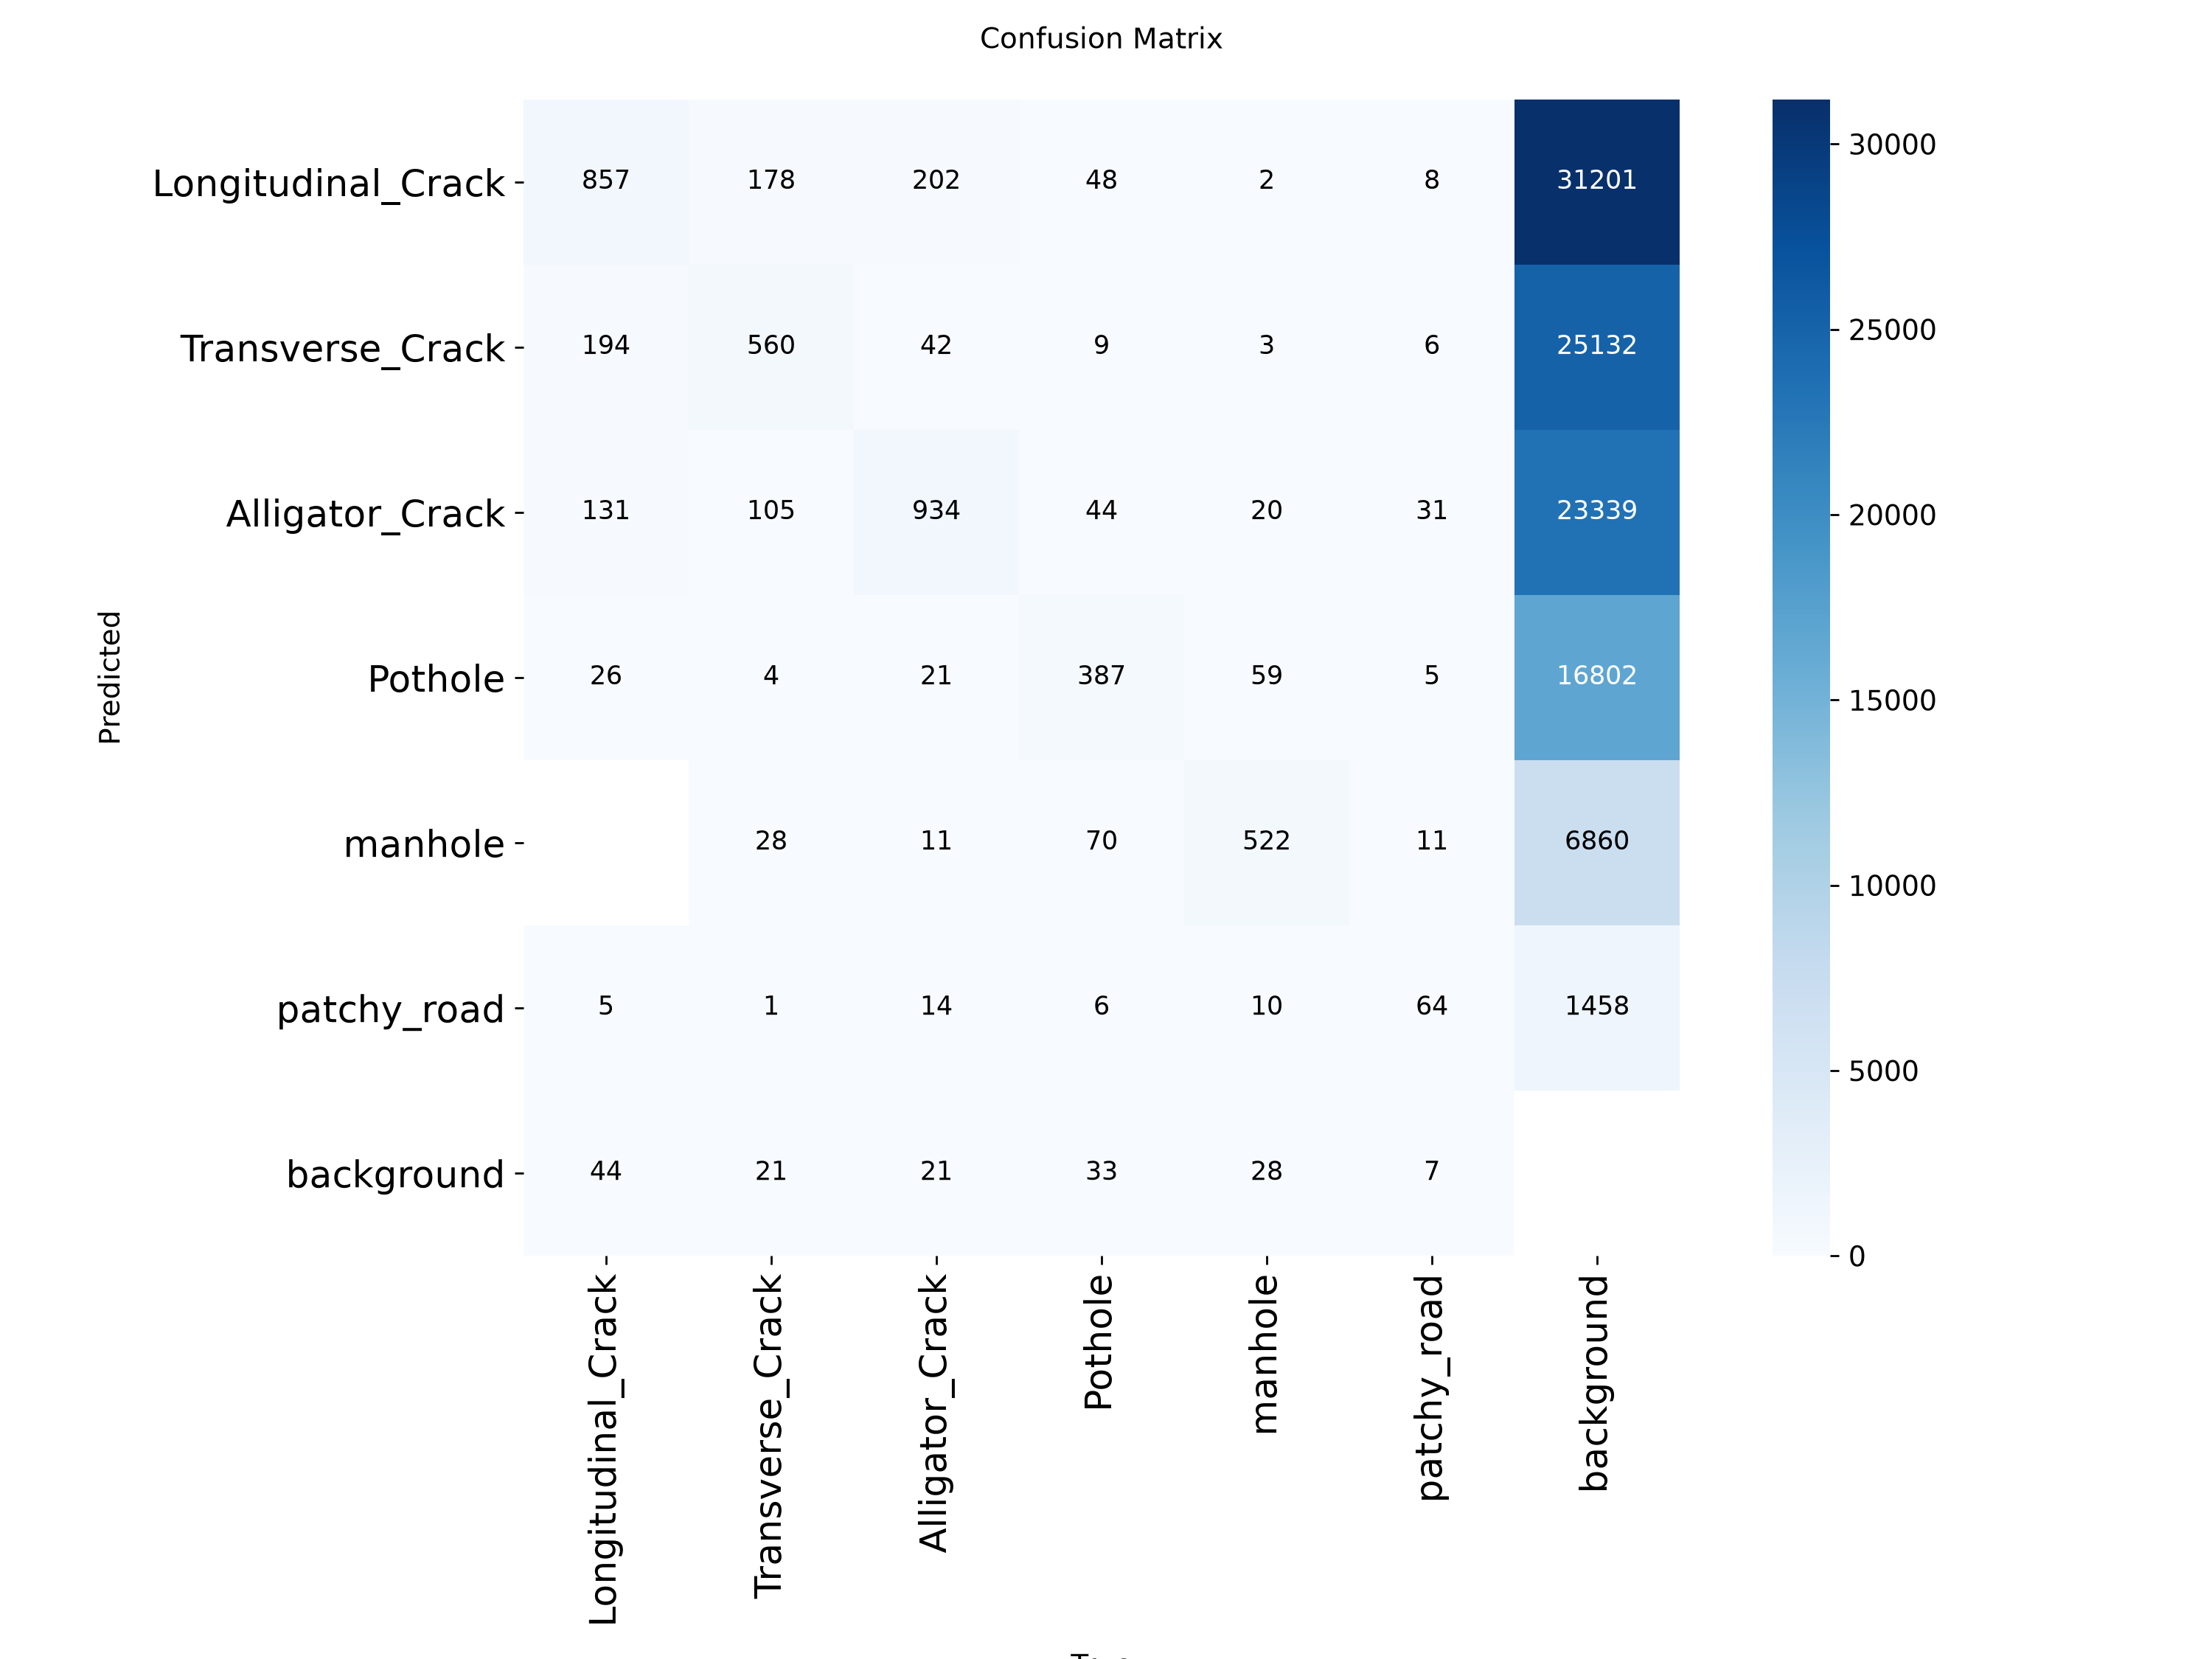

  val — confusion_matrix_normalized.png


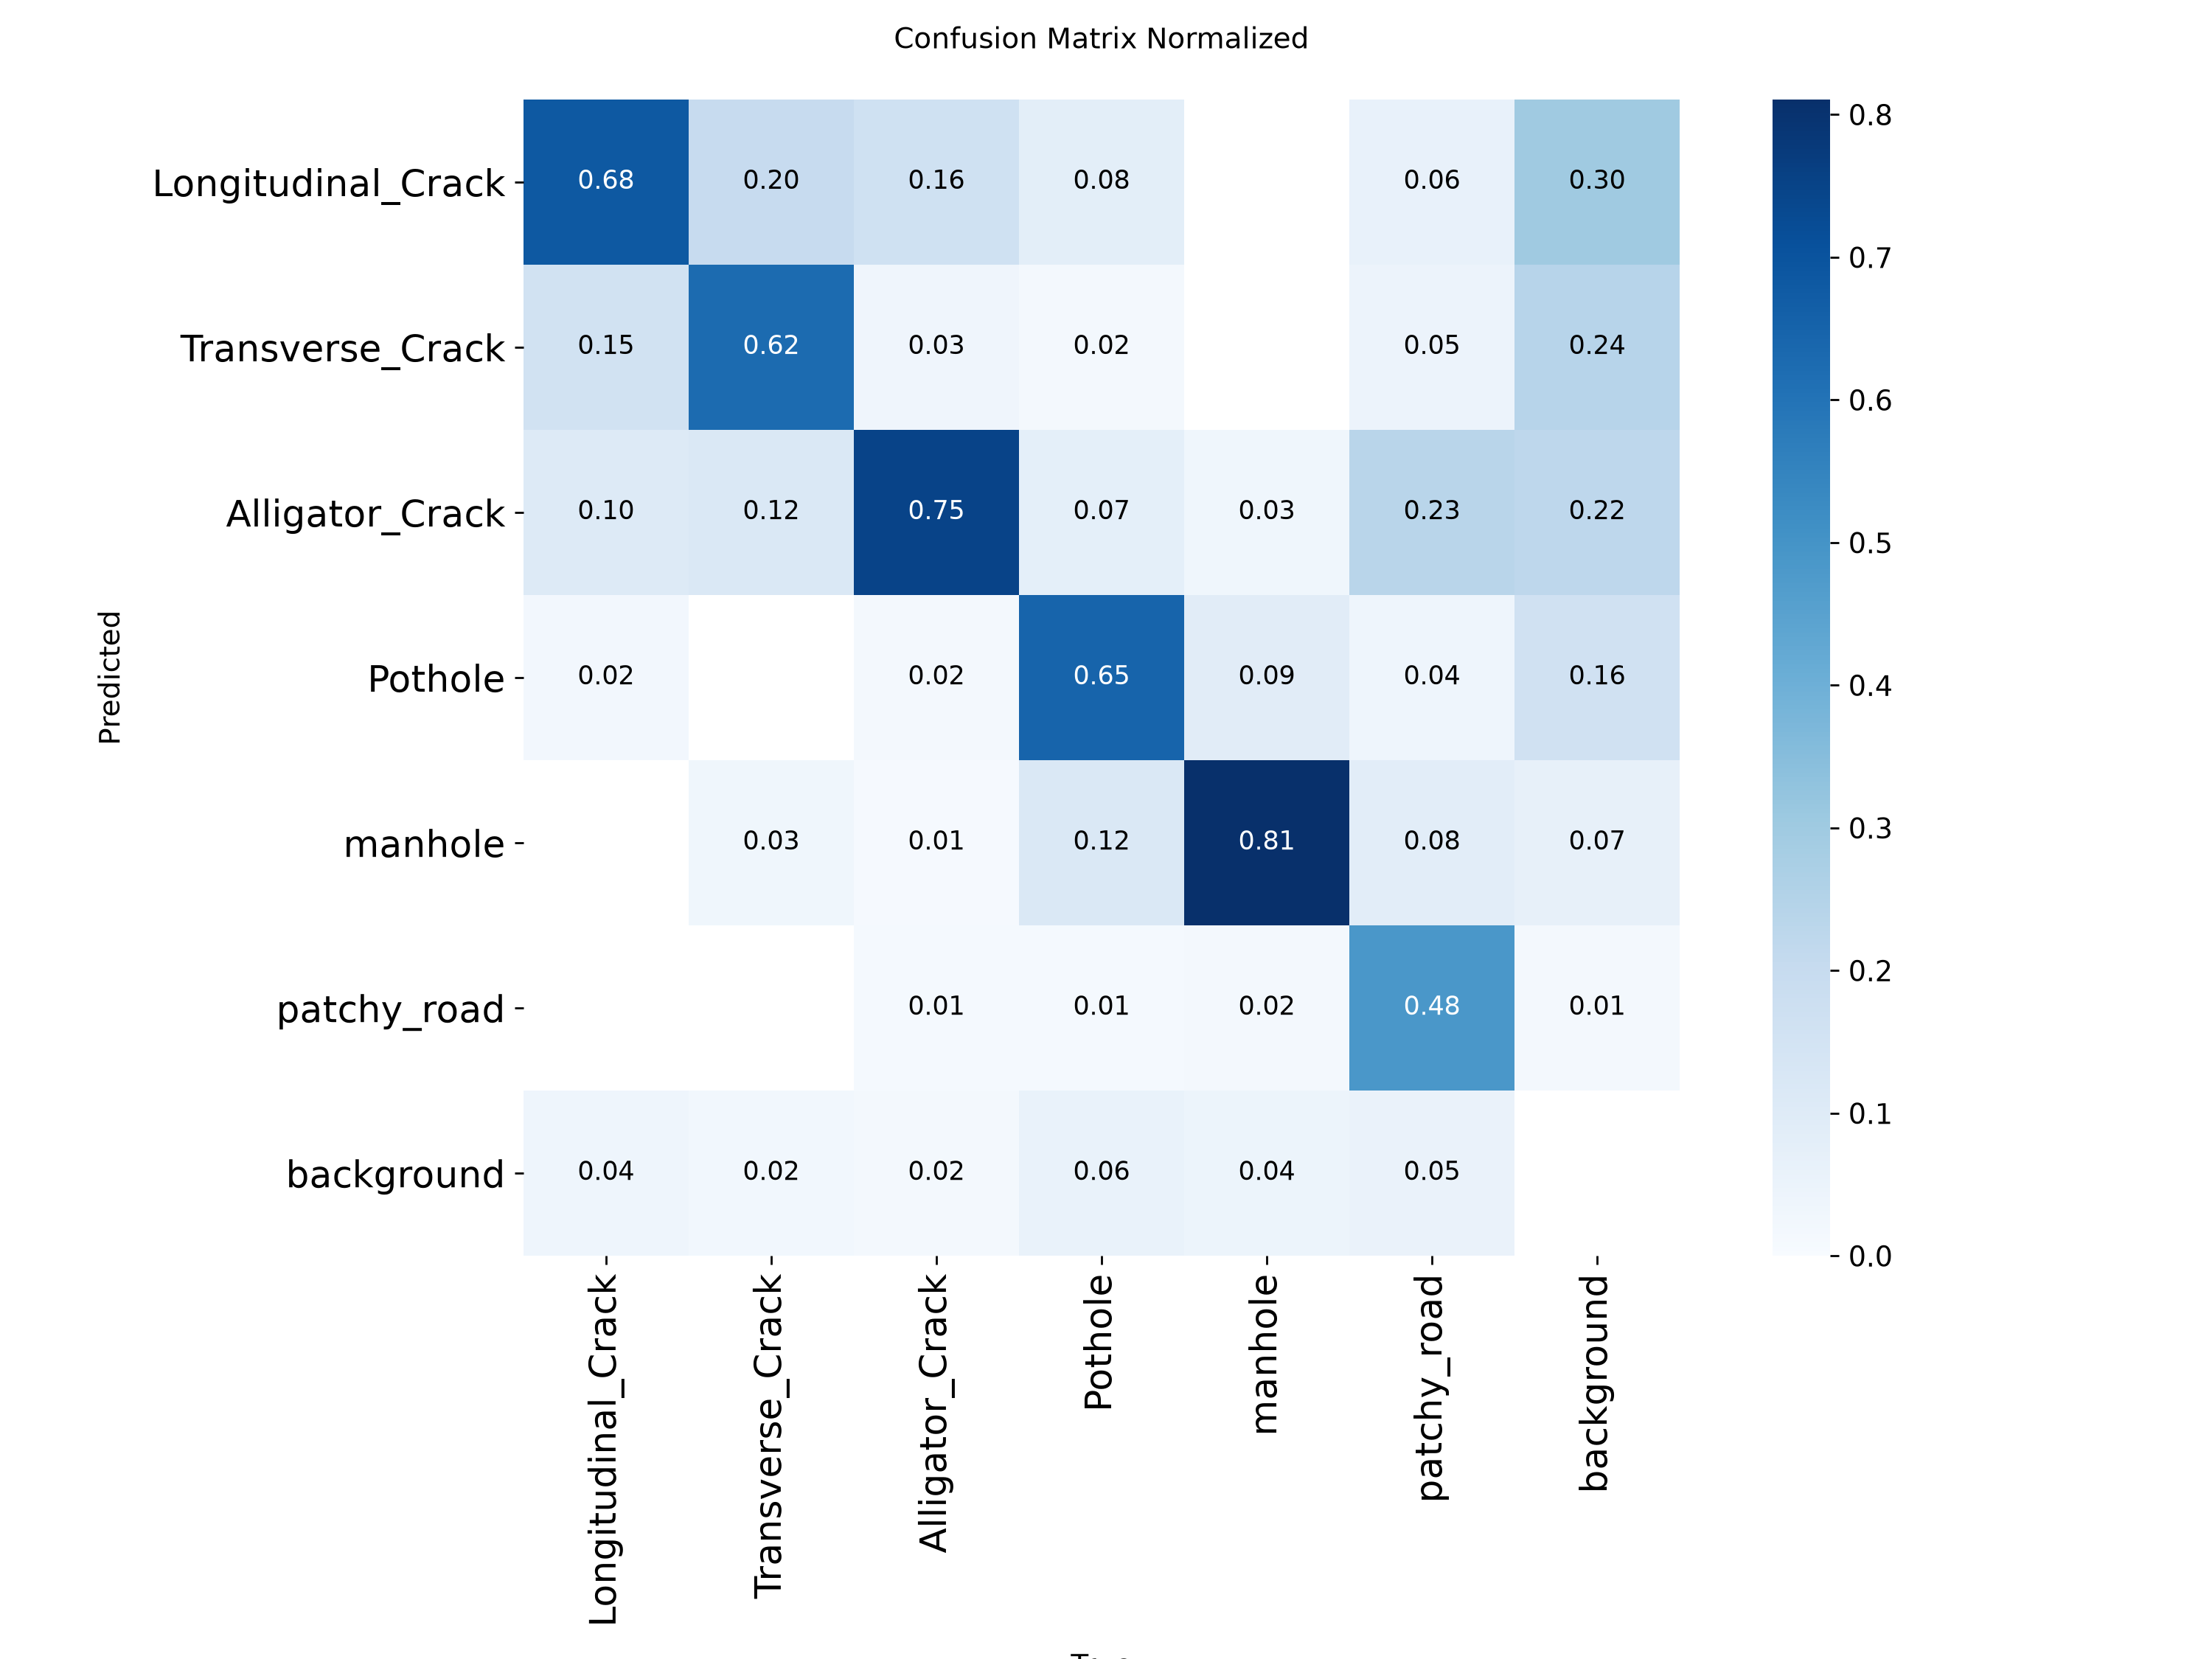

  test — confusion_matrix.png


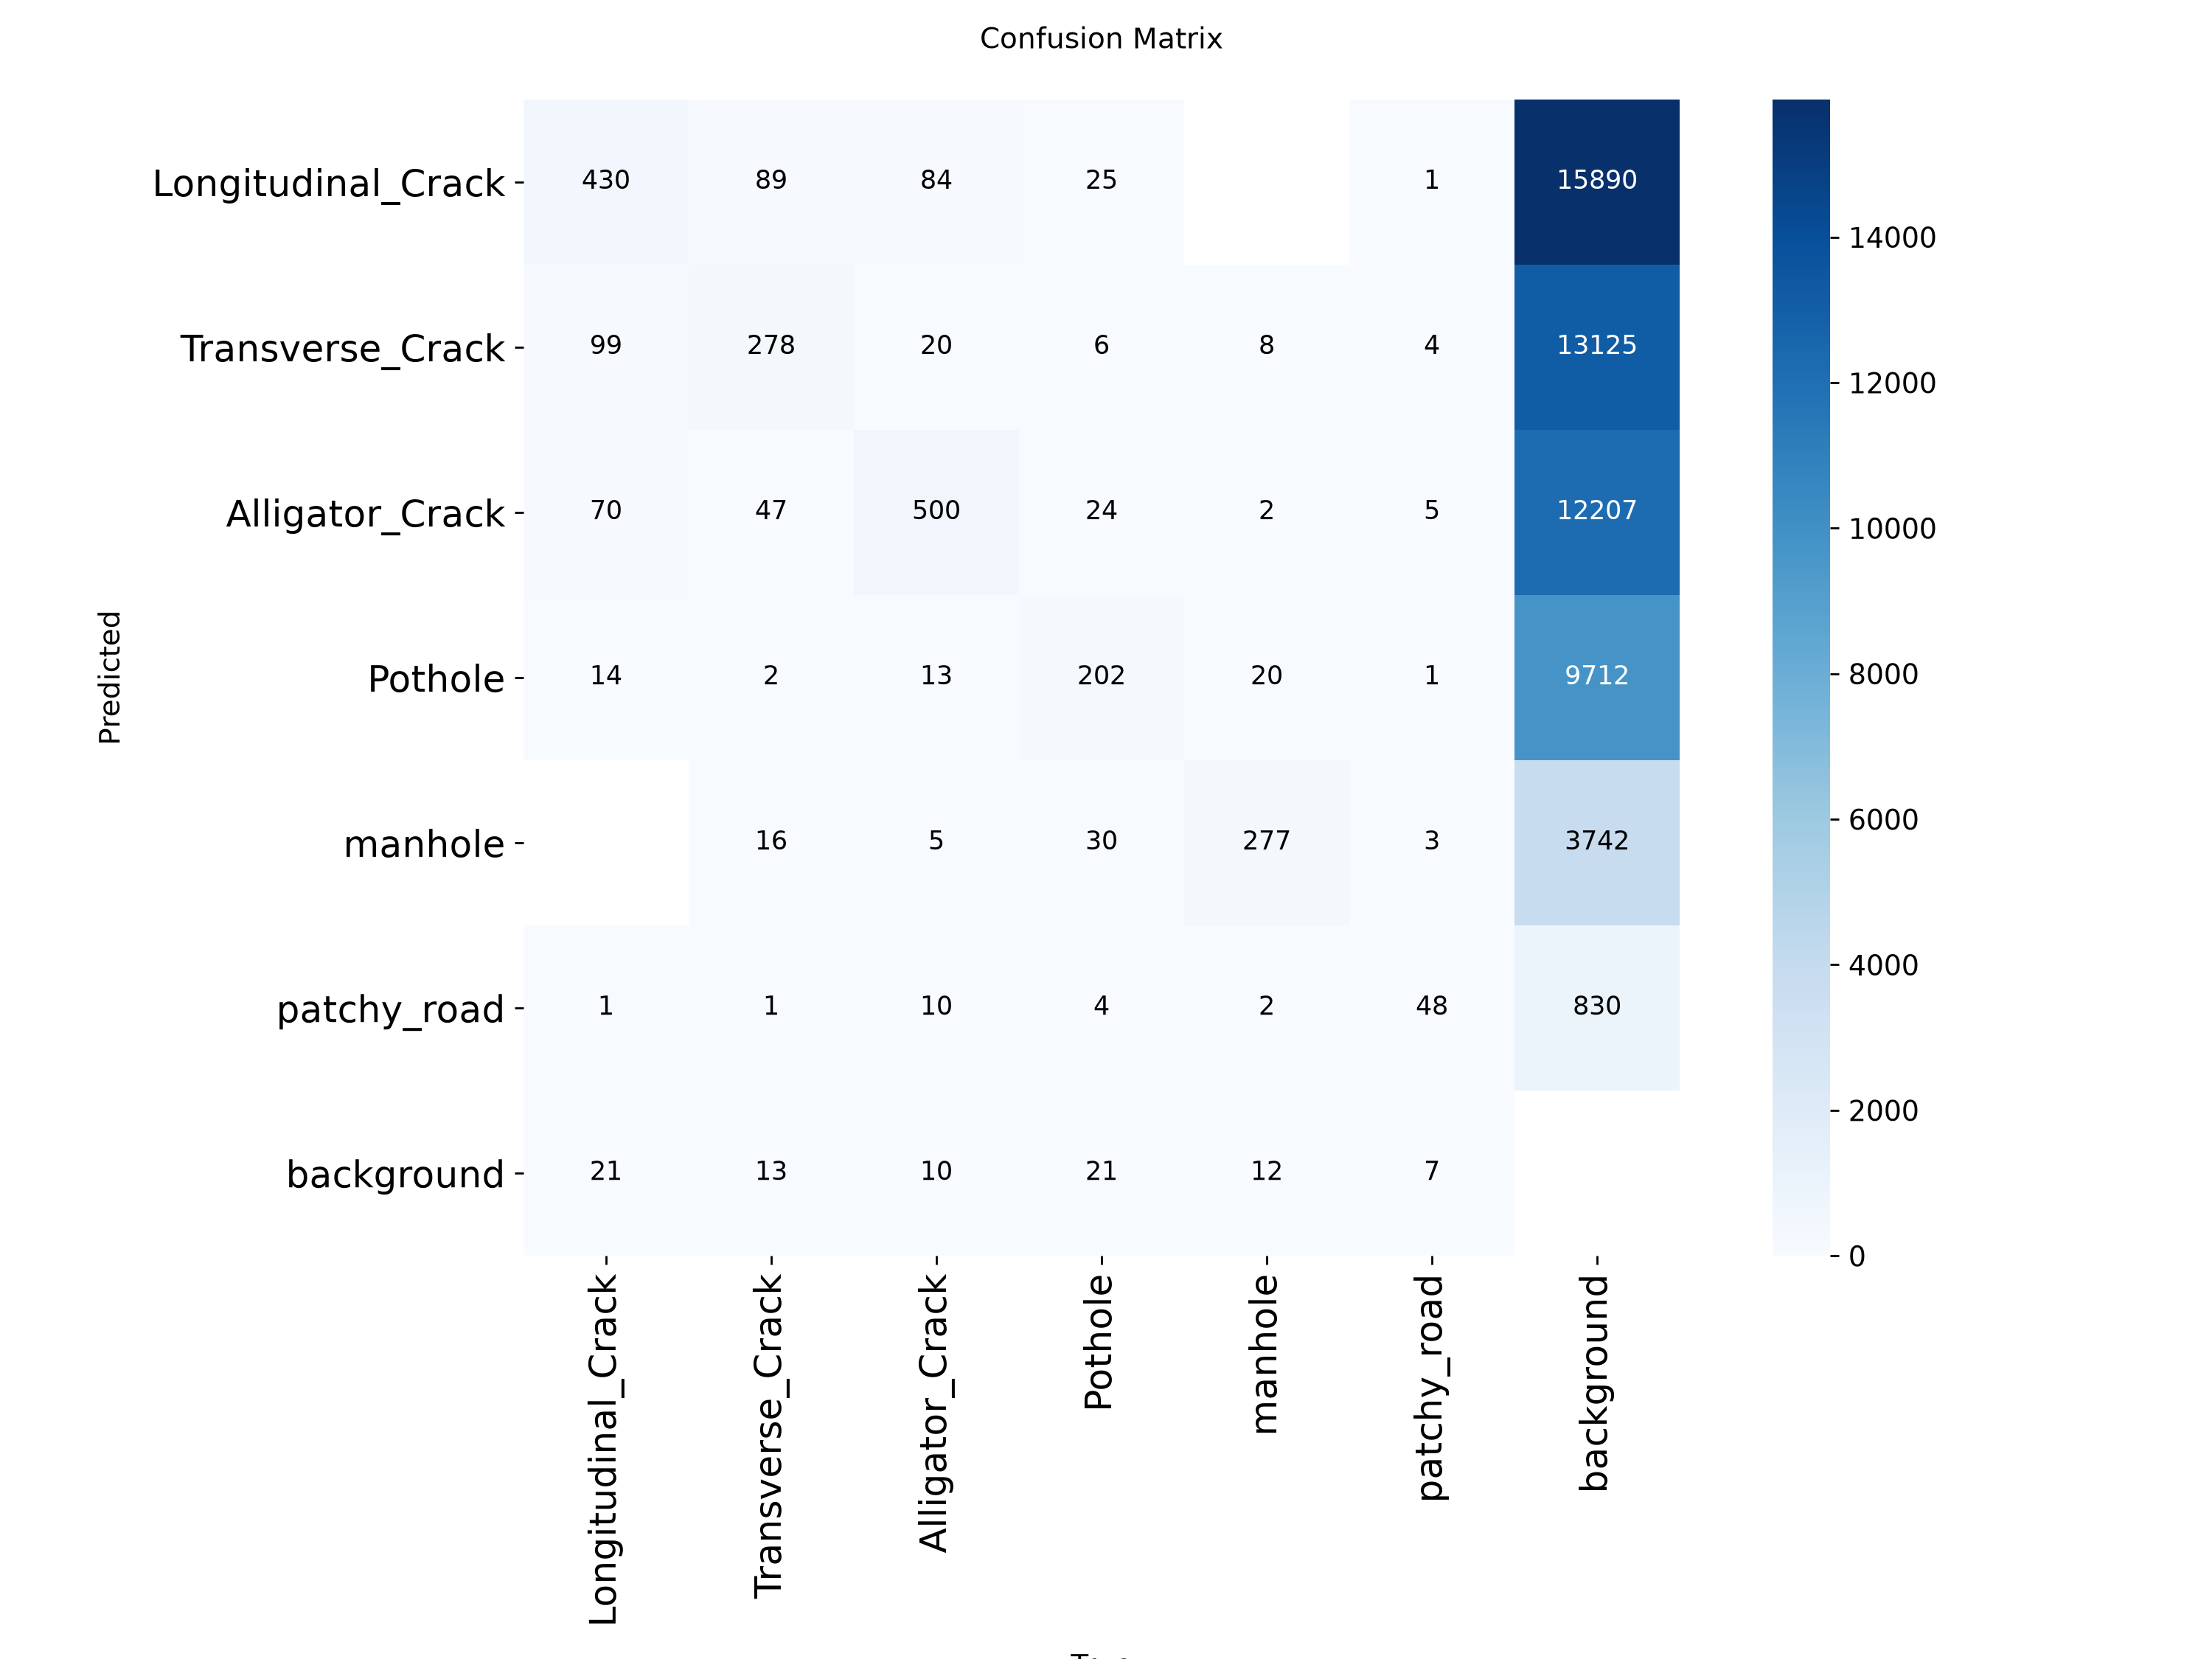

  test — confusion_matrix_normalized.png


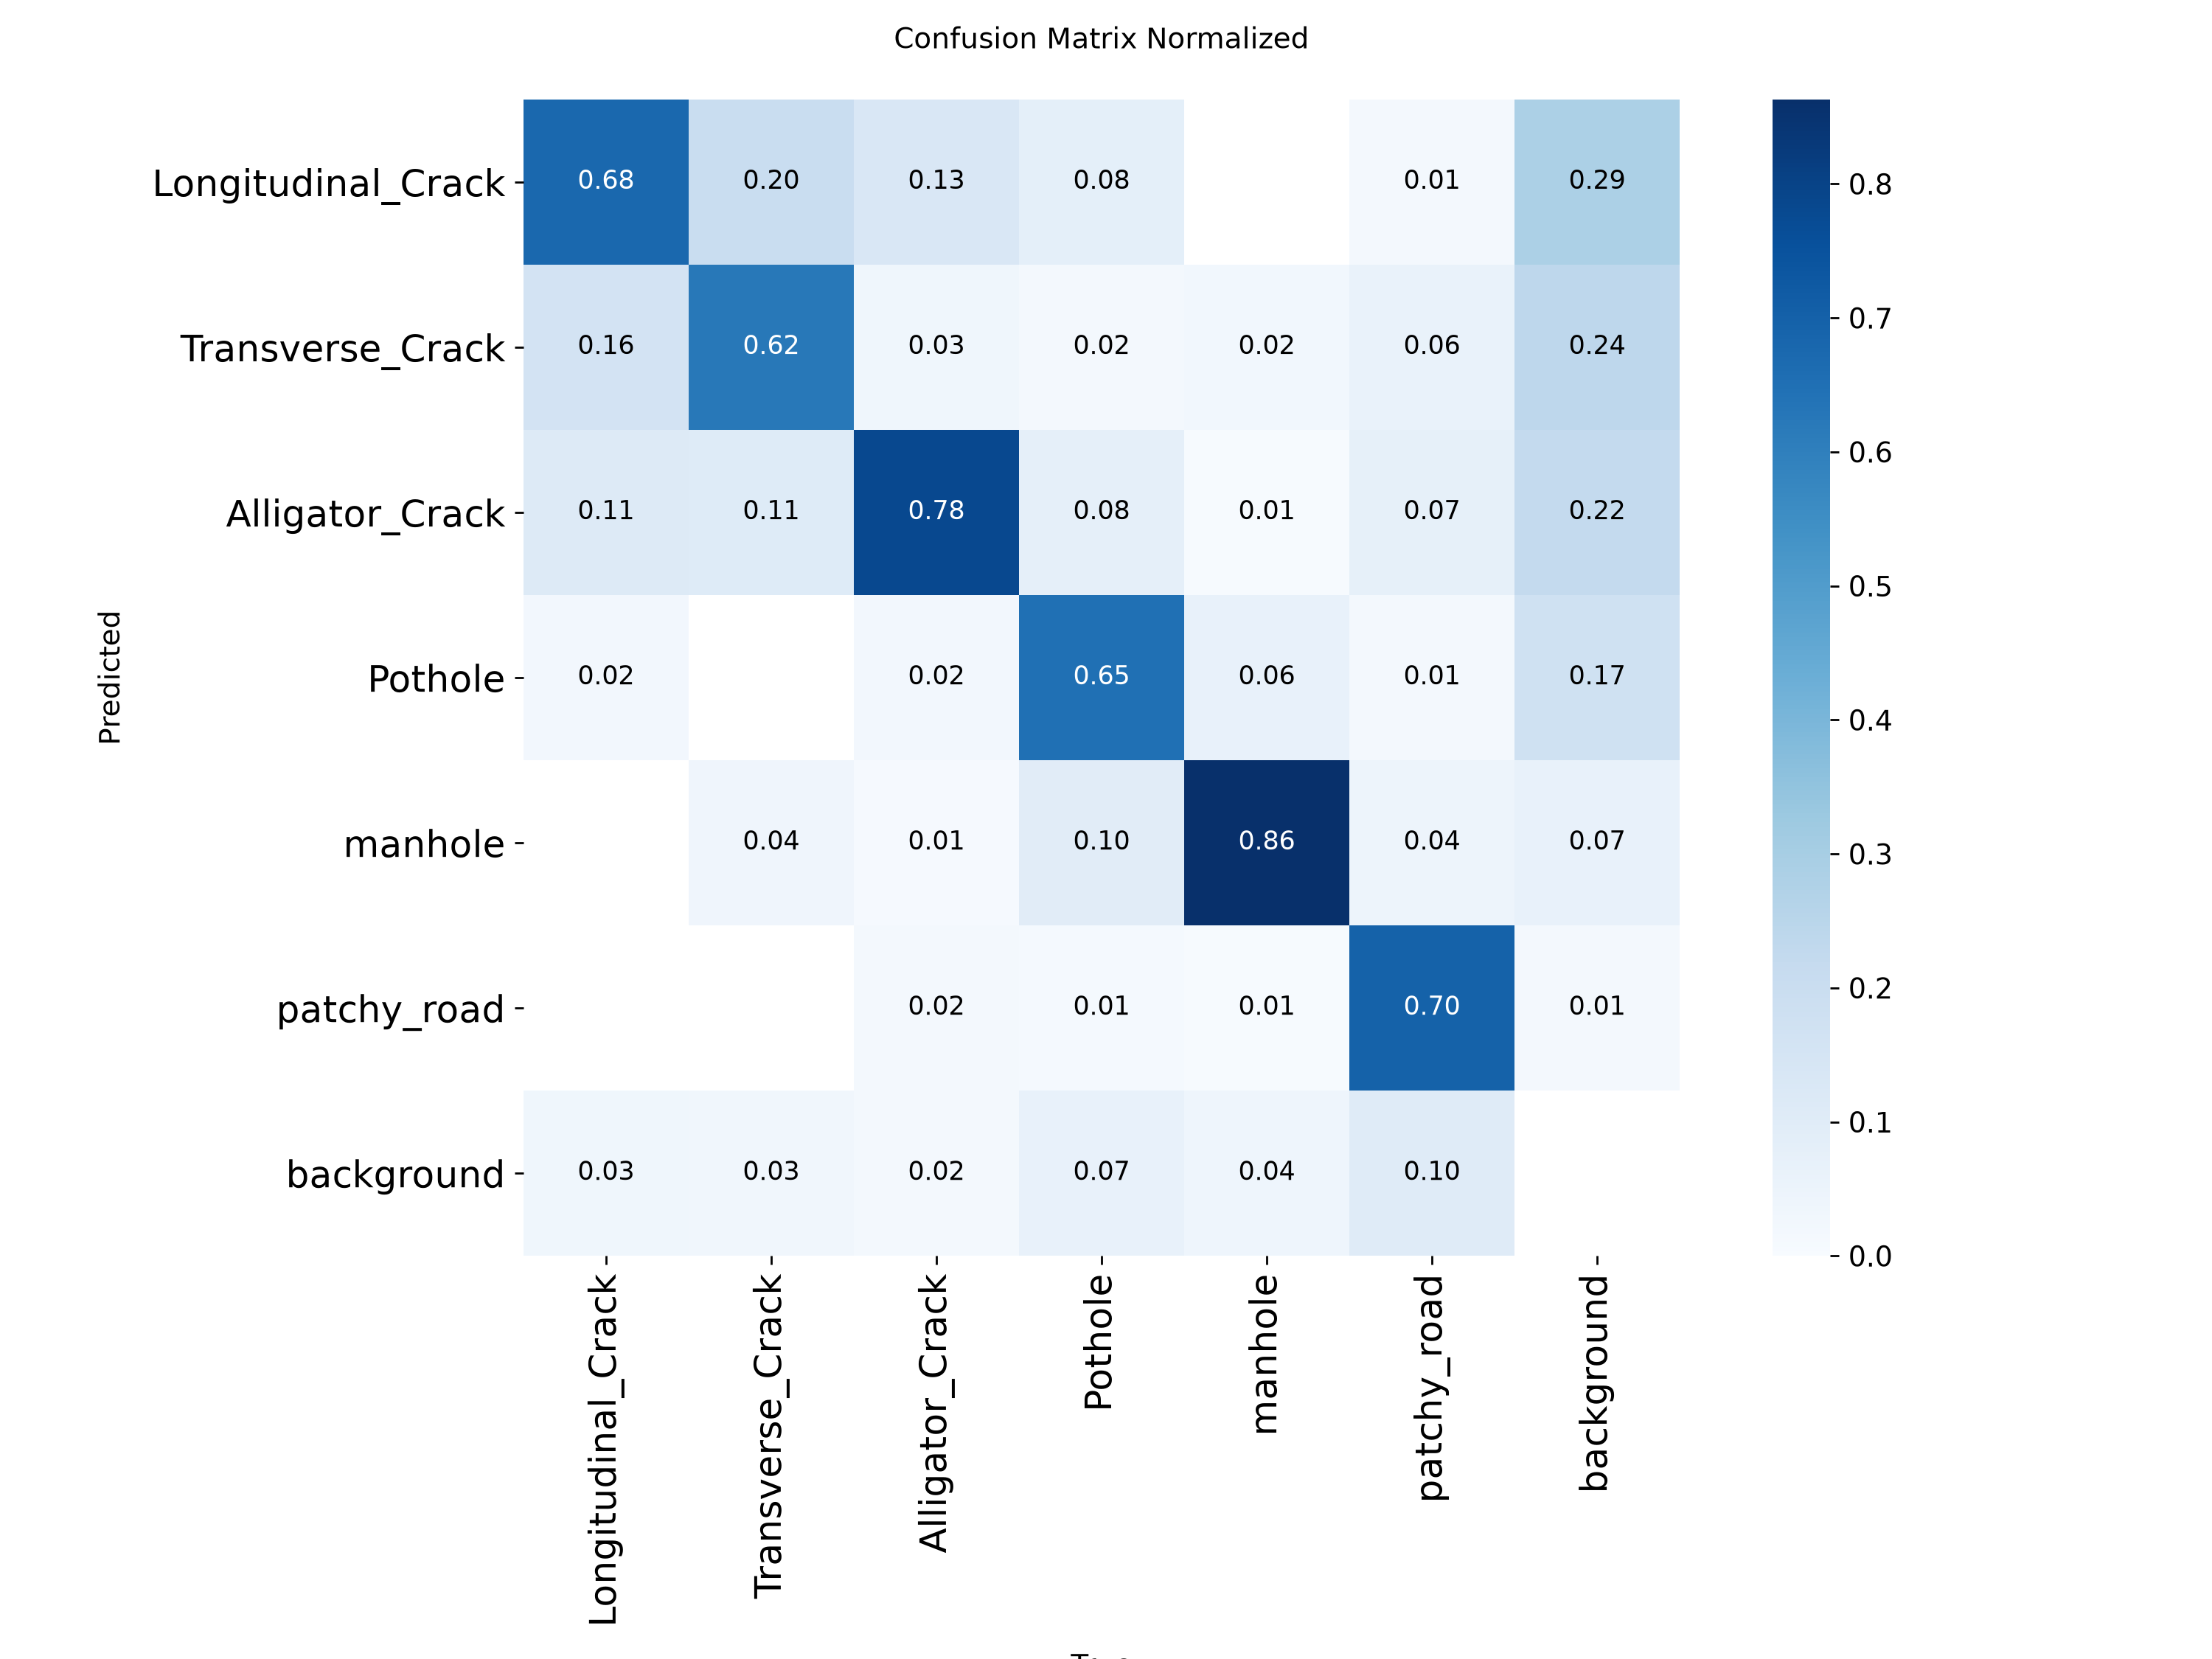


──────────────────────────────────────────────────
Model: yolov12n_class_weight
  val — confusion_matrix.png


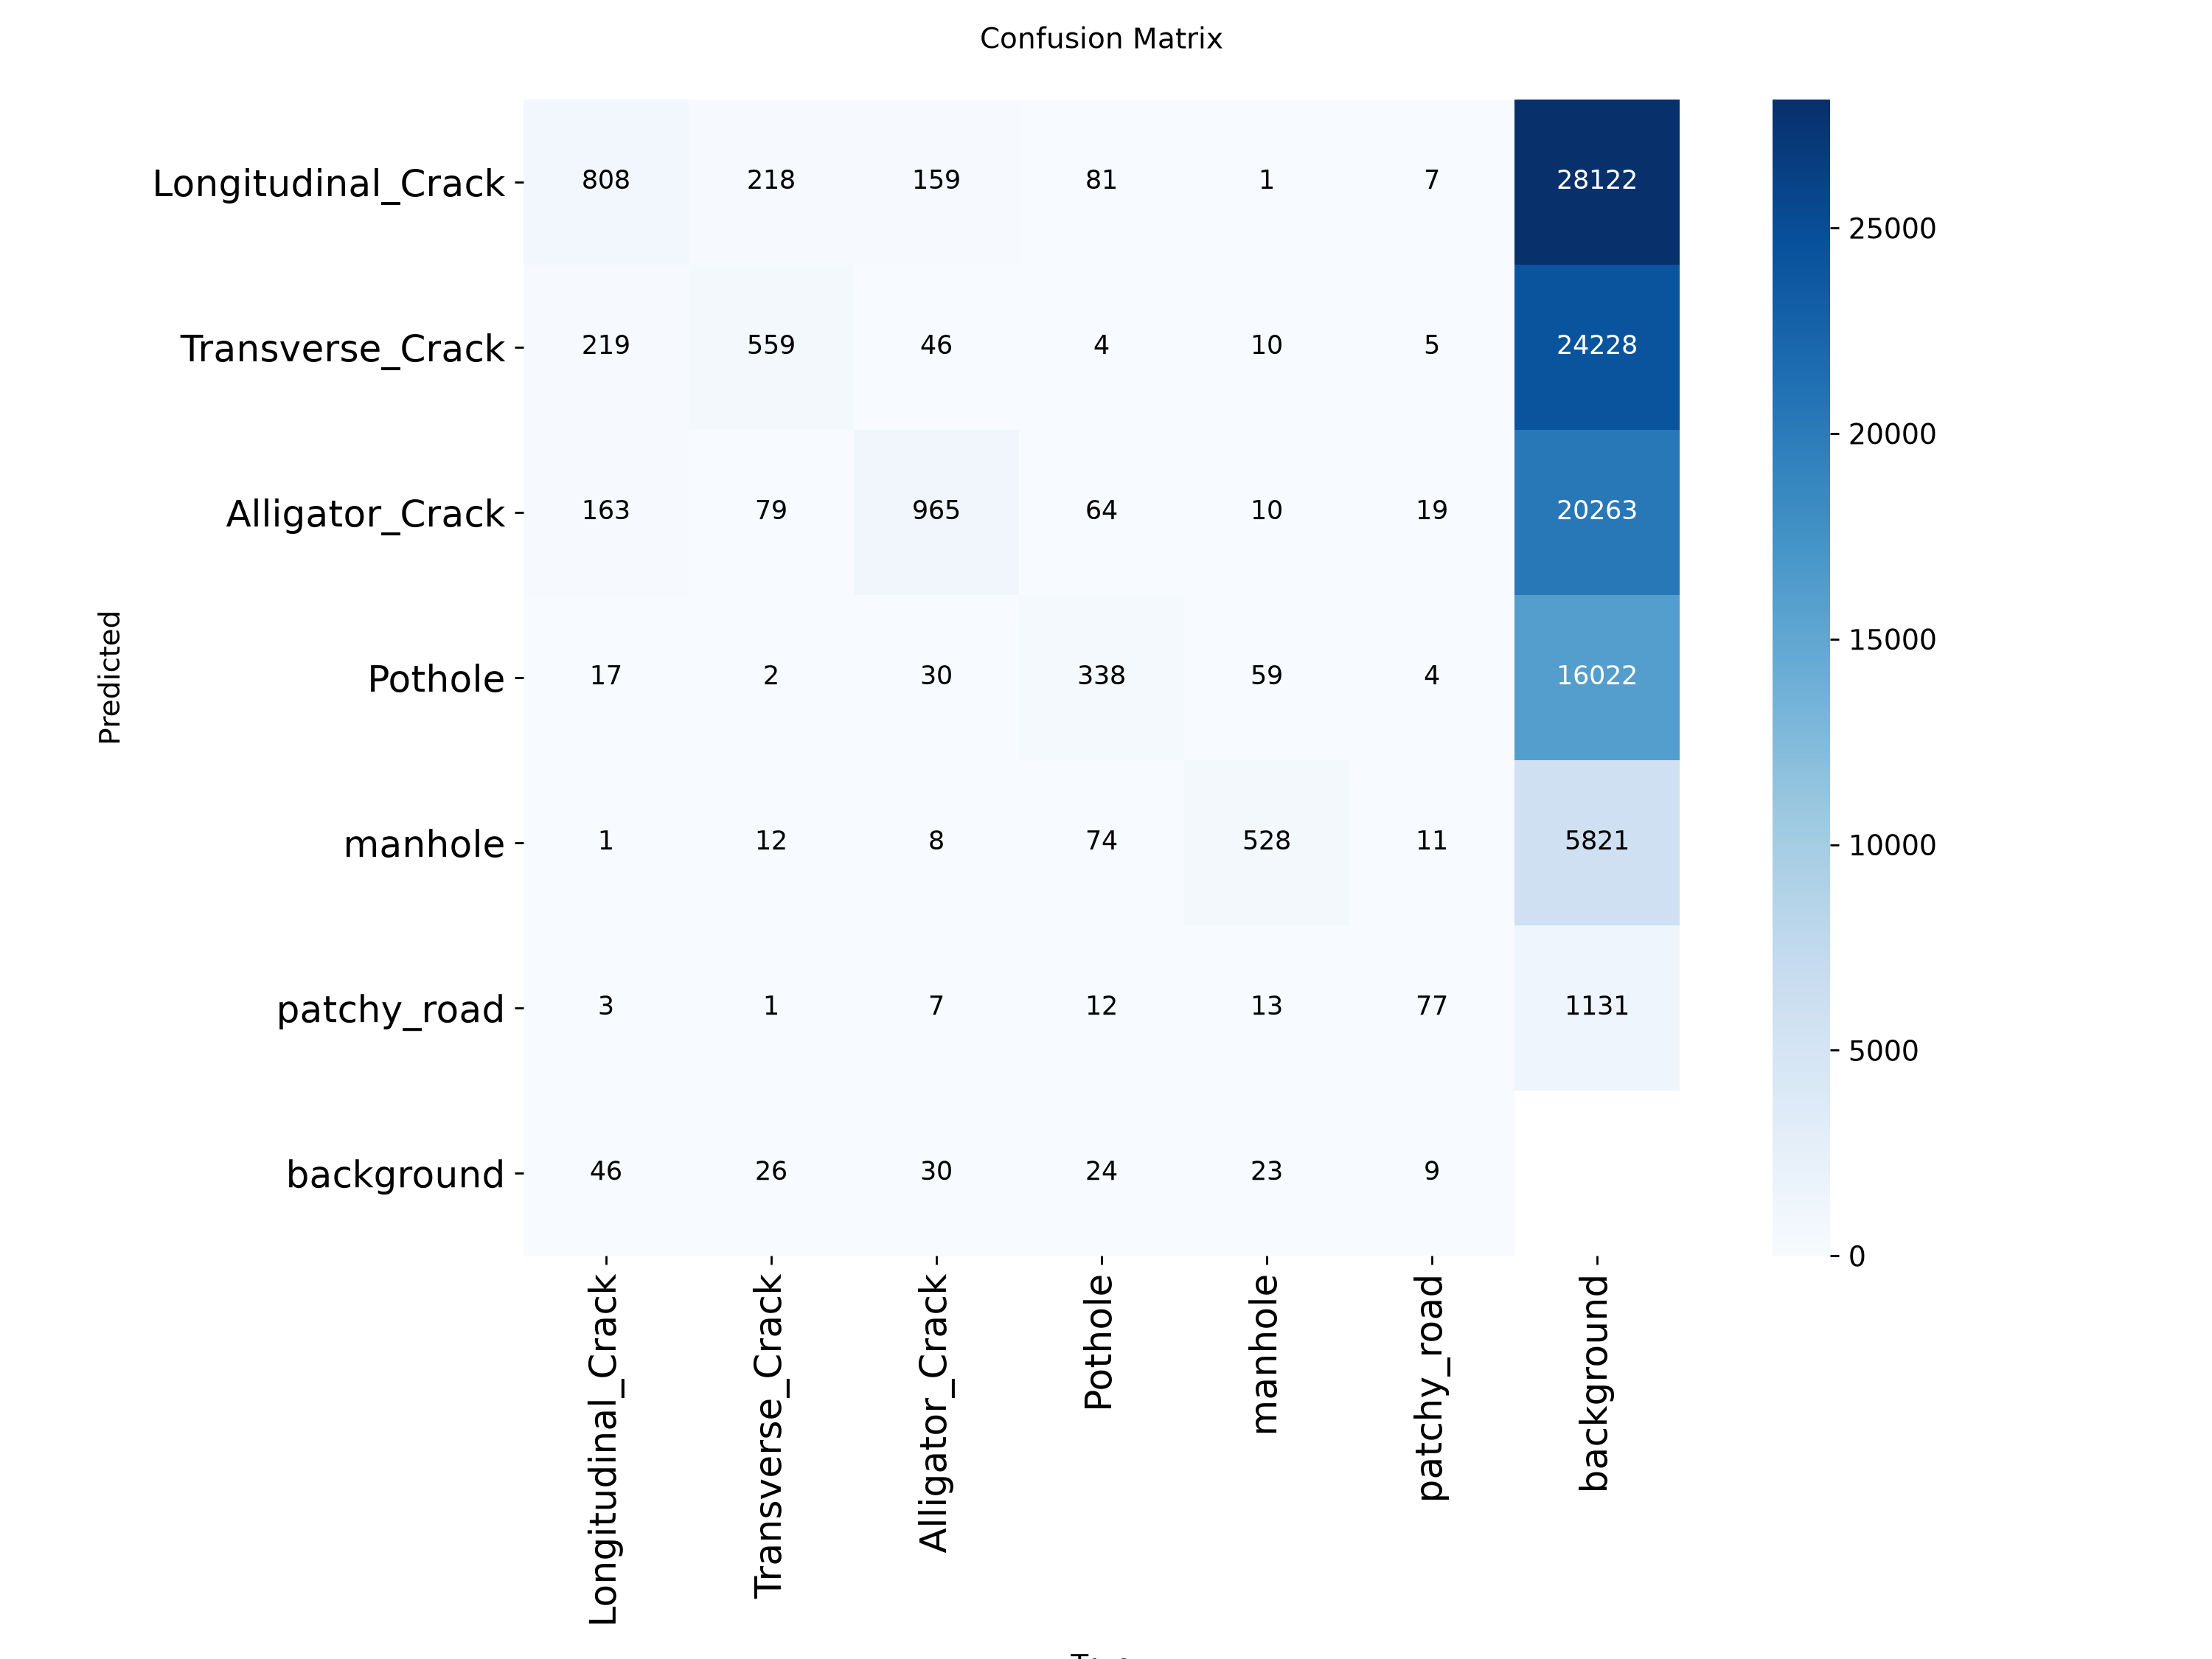

  val — confusion_matrix_normalized.png


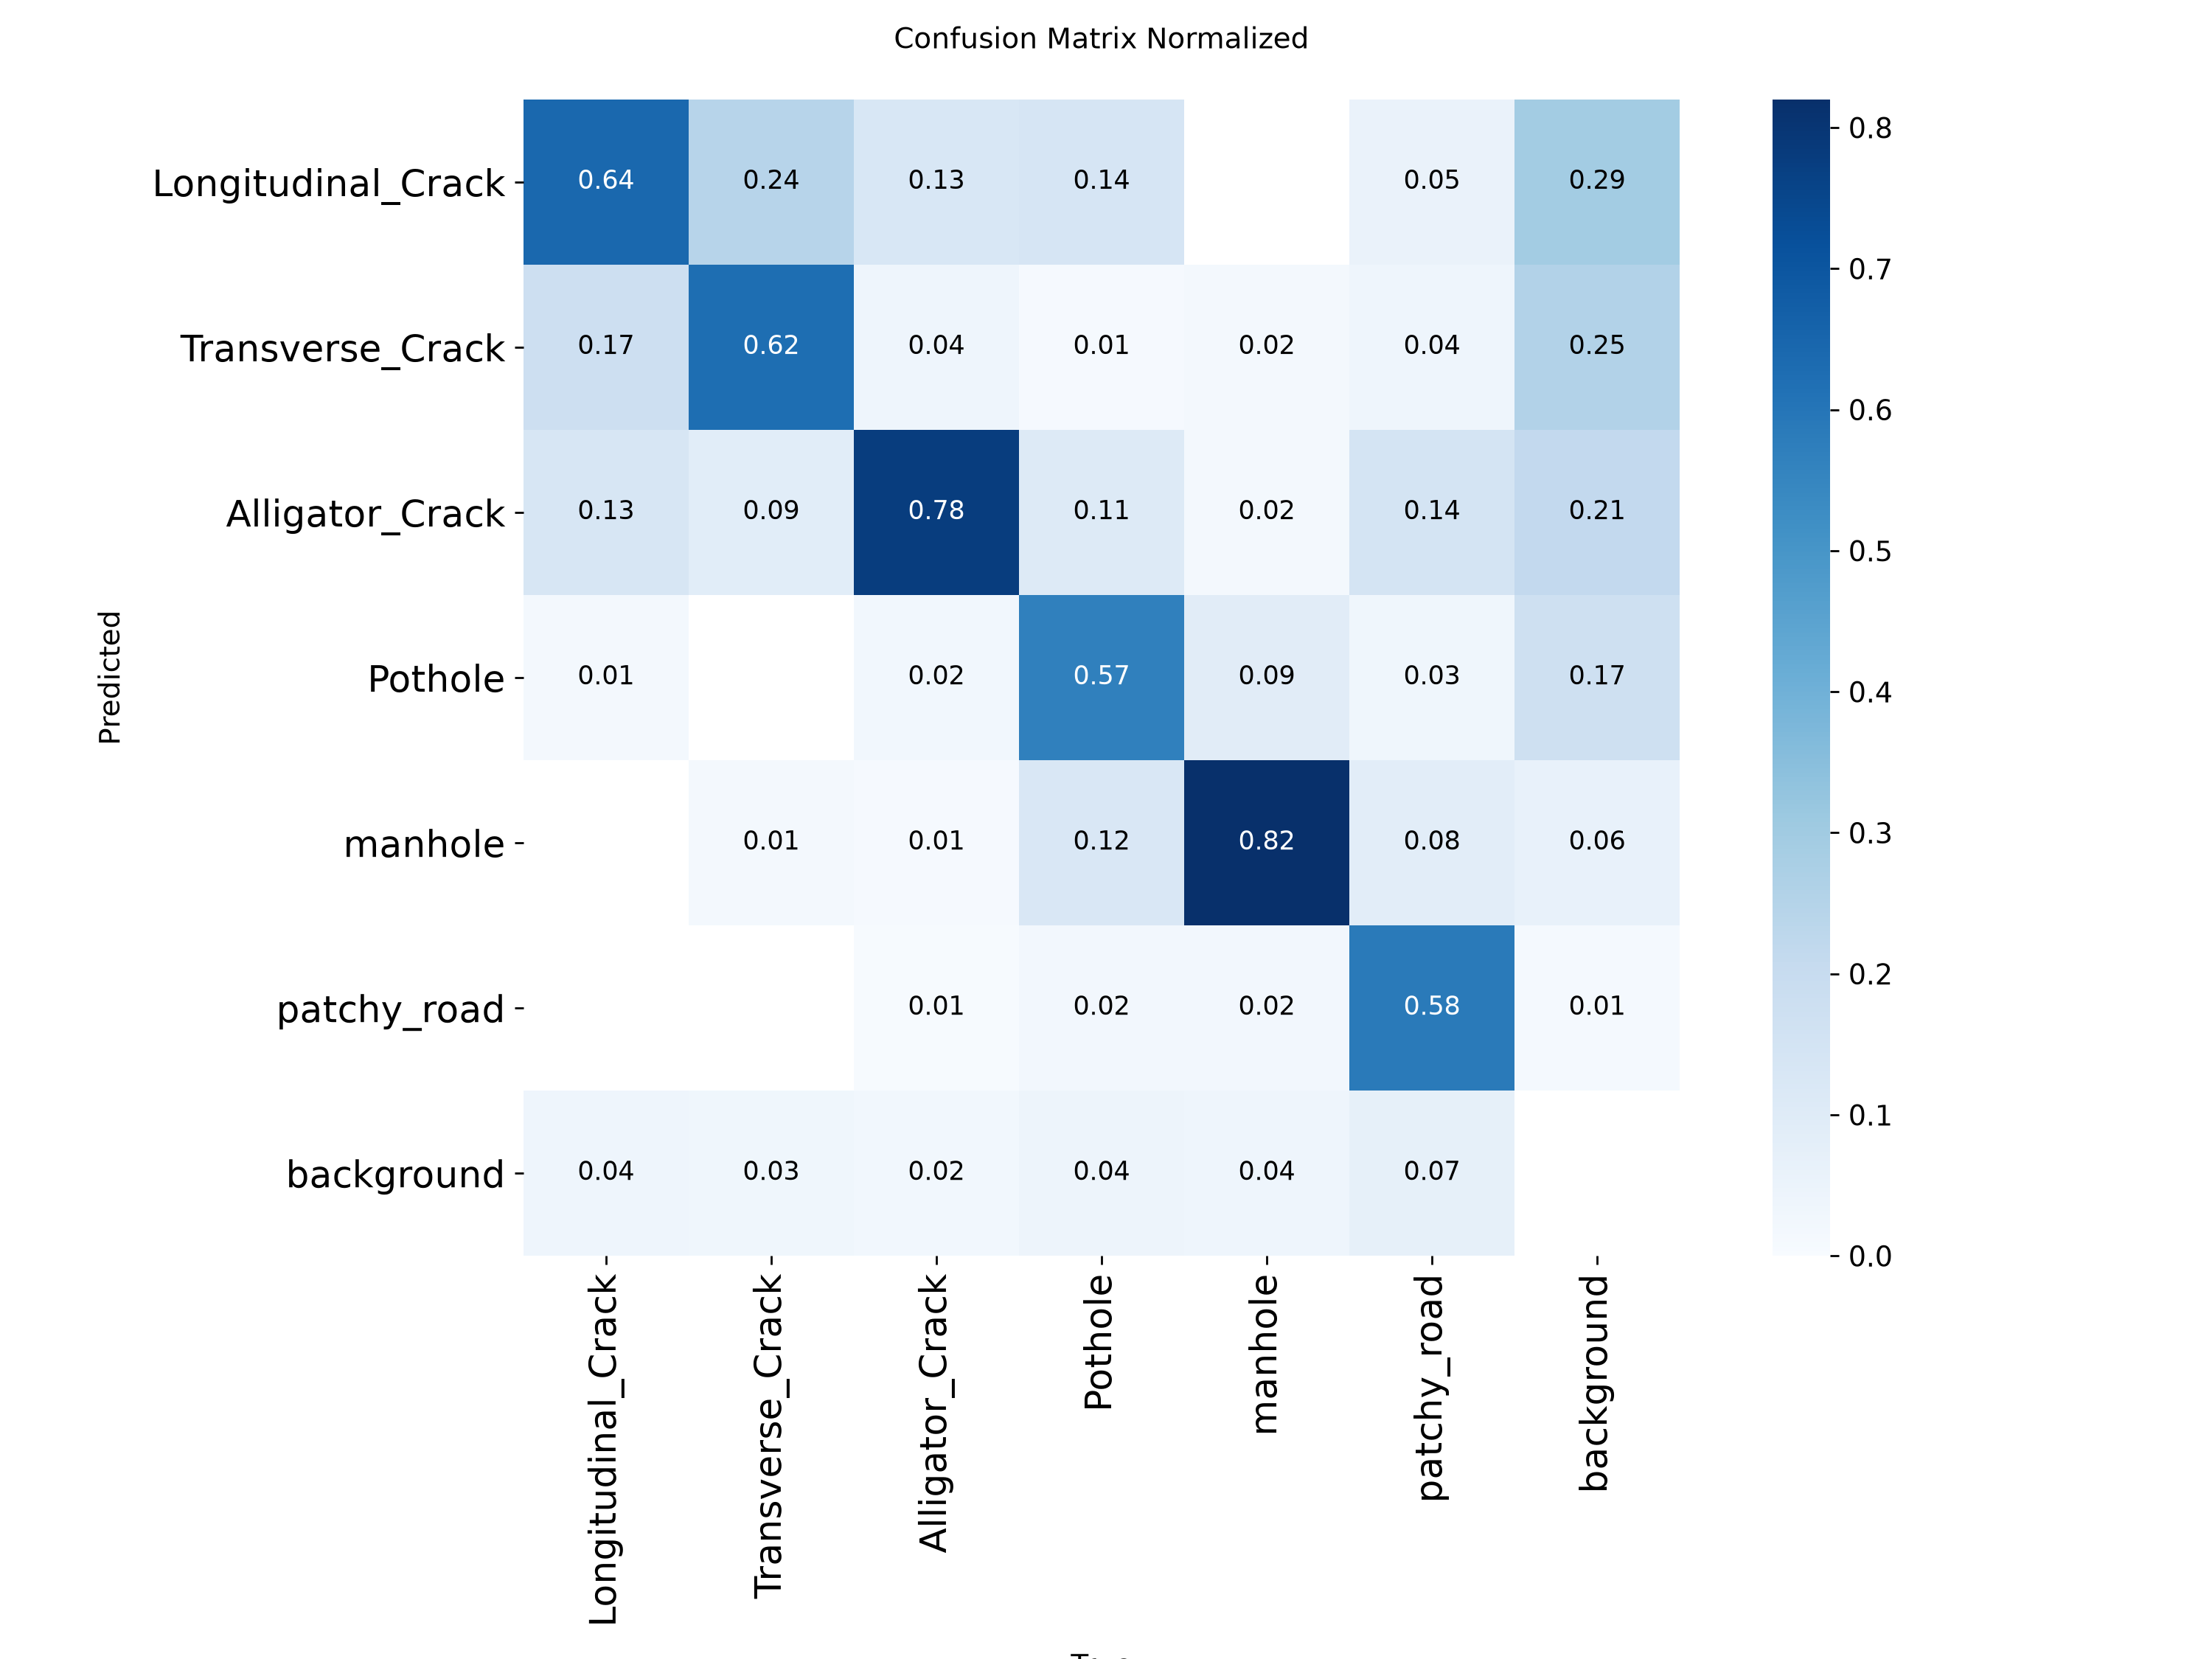

  test — confusion_matrix.png


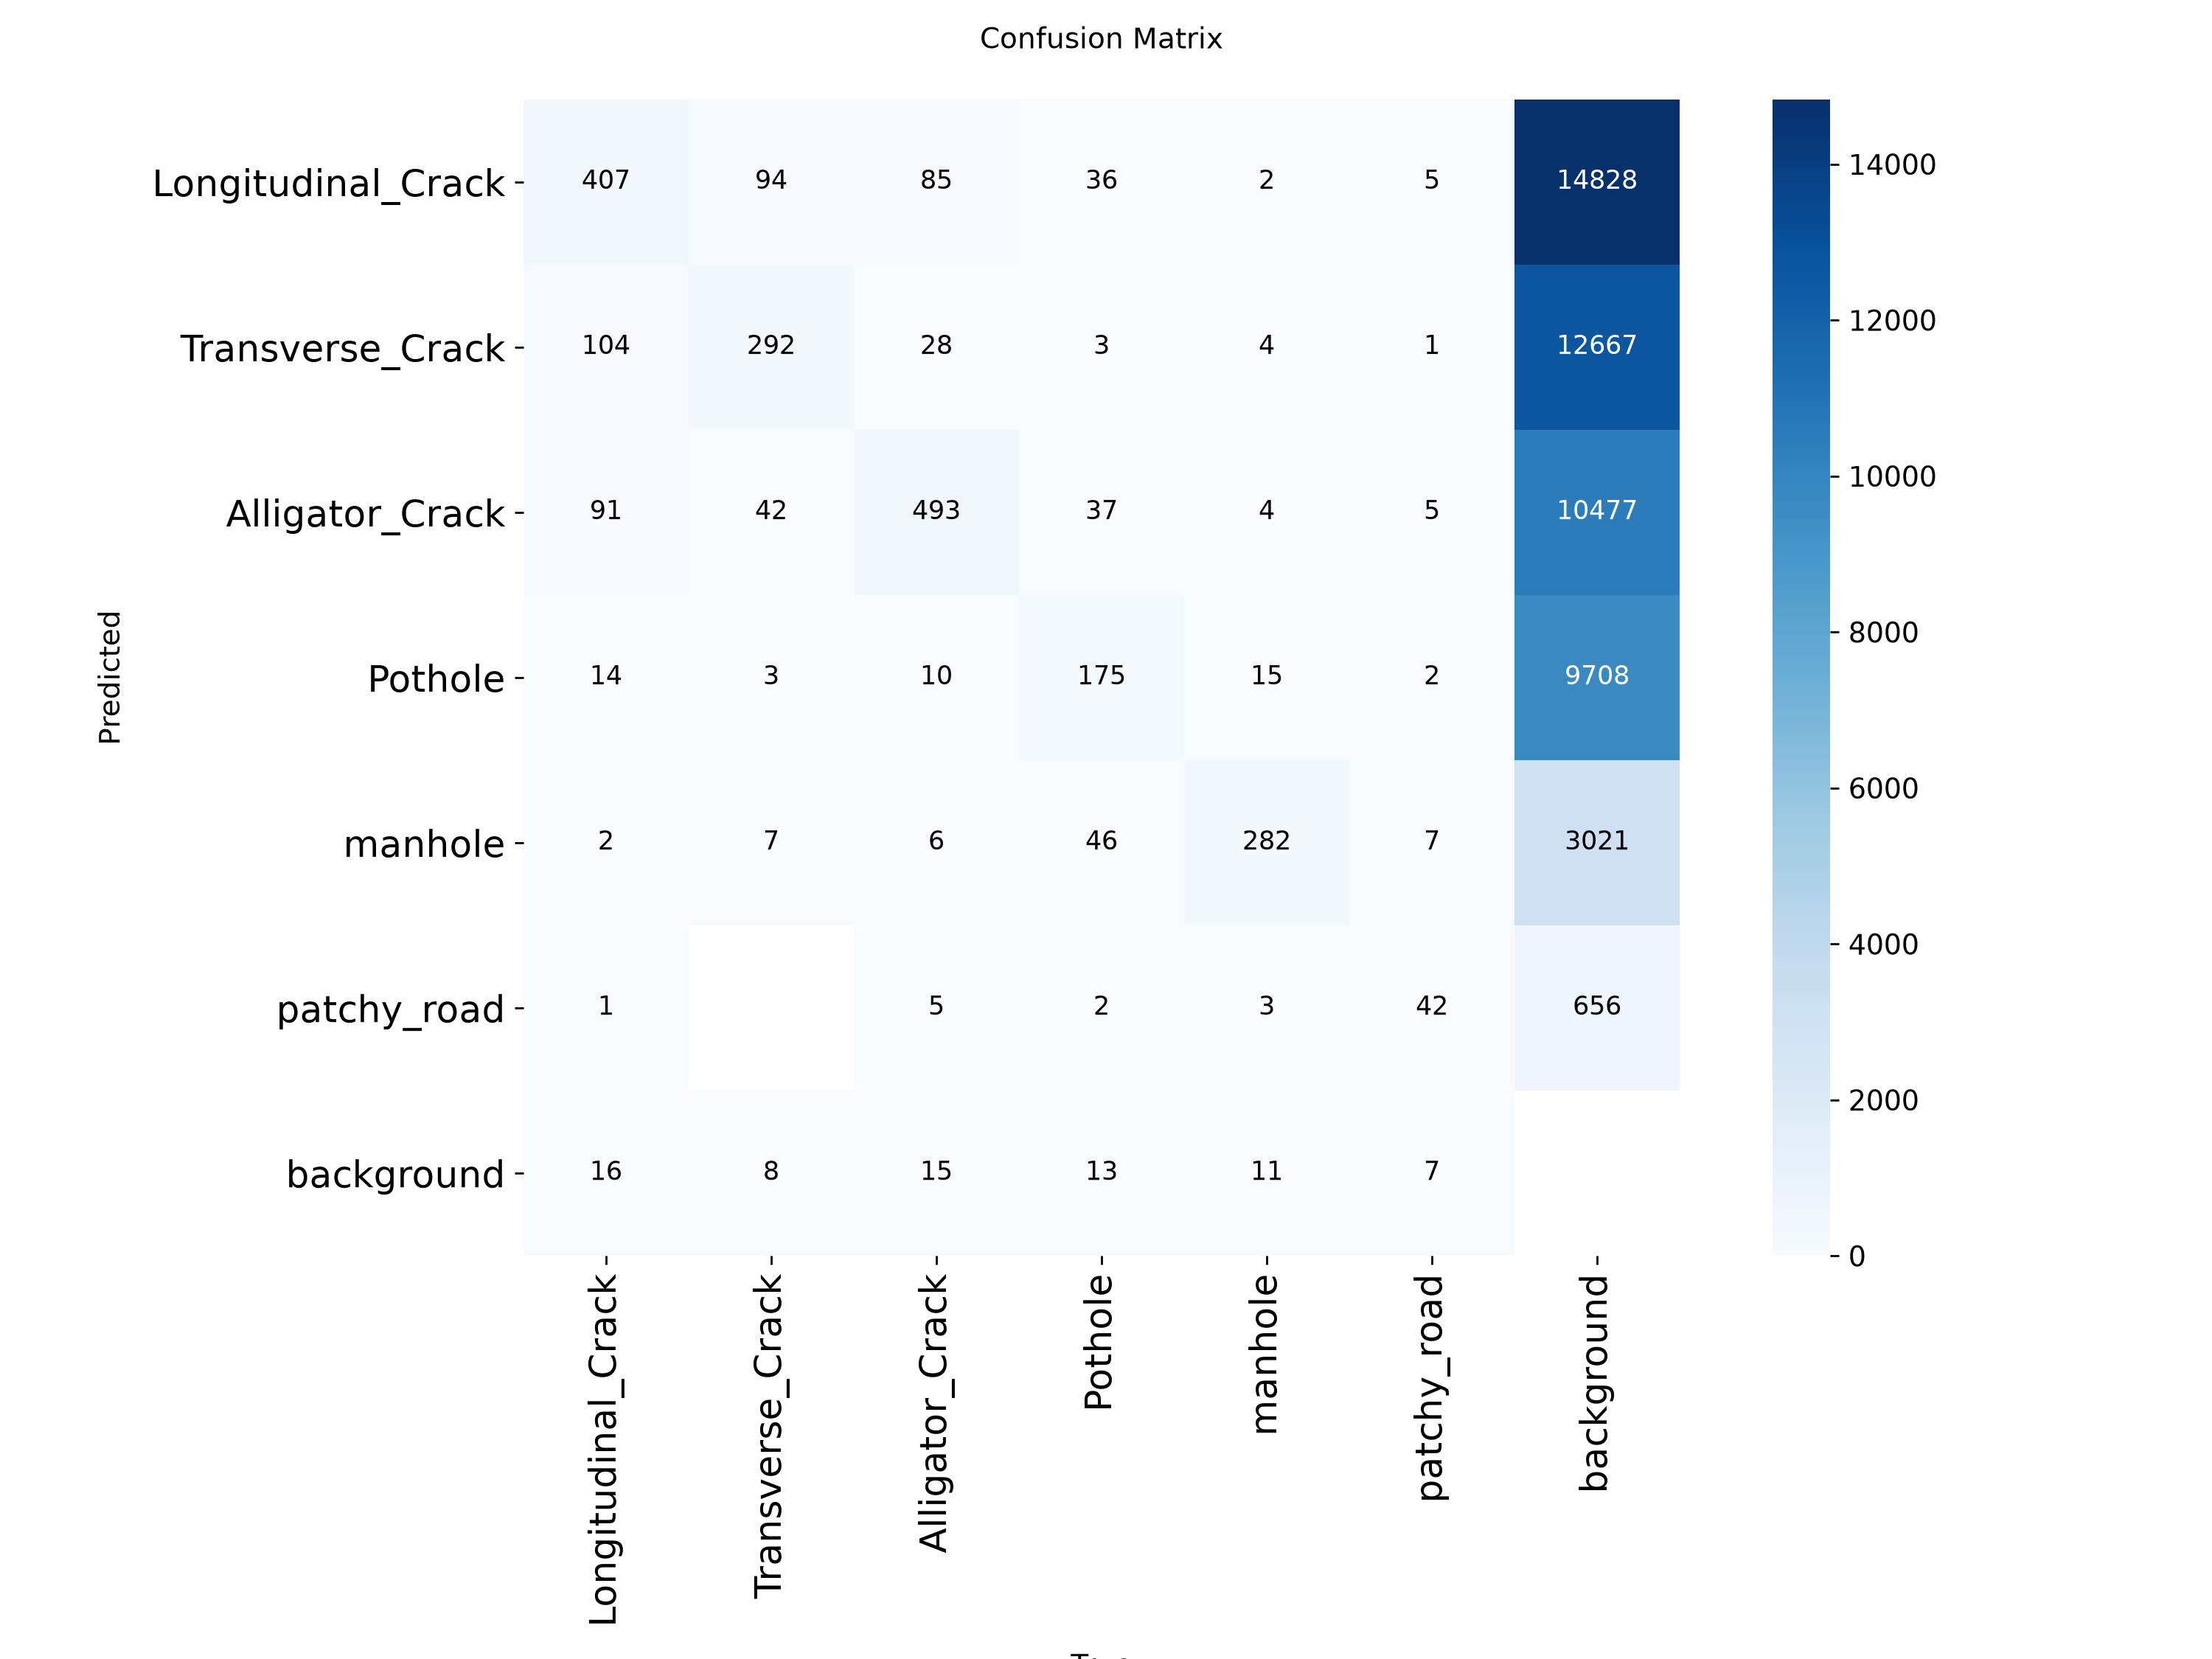

  test — confusion_matrix_normalized.png


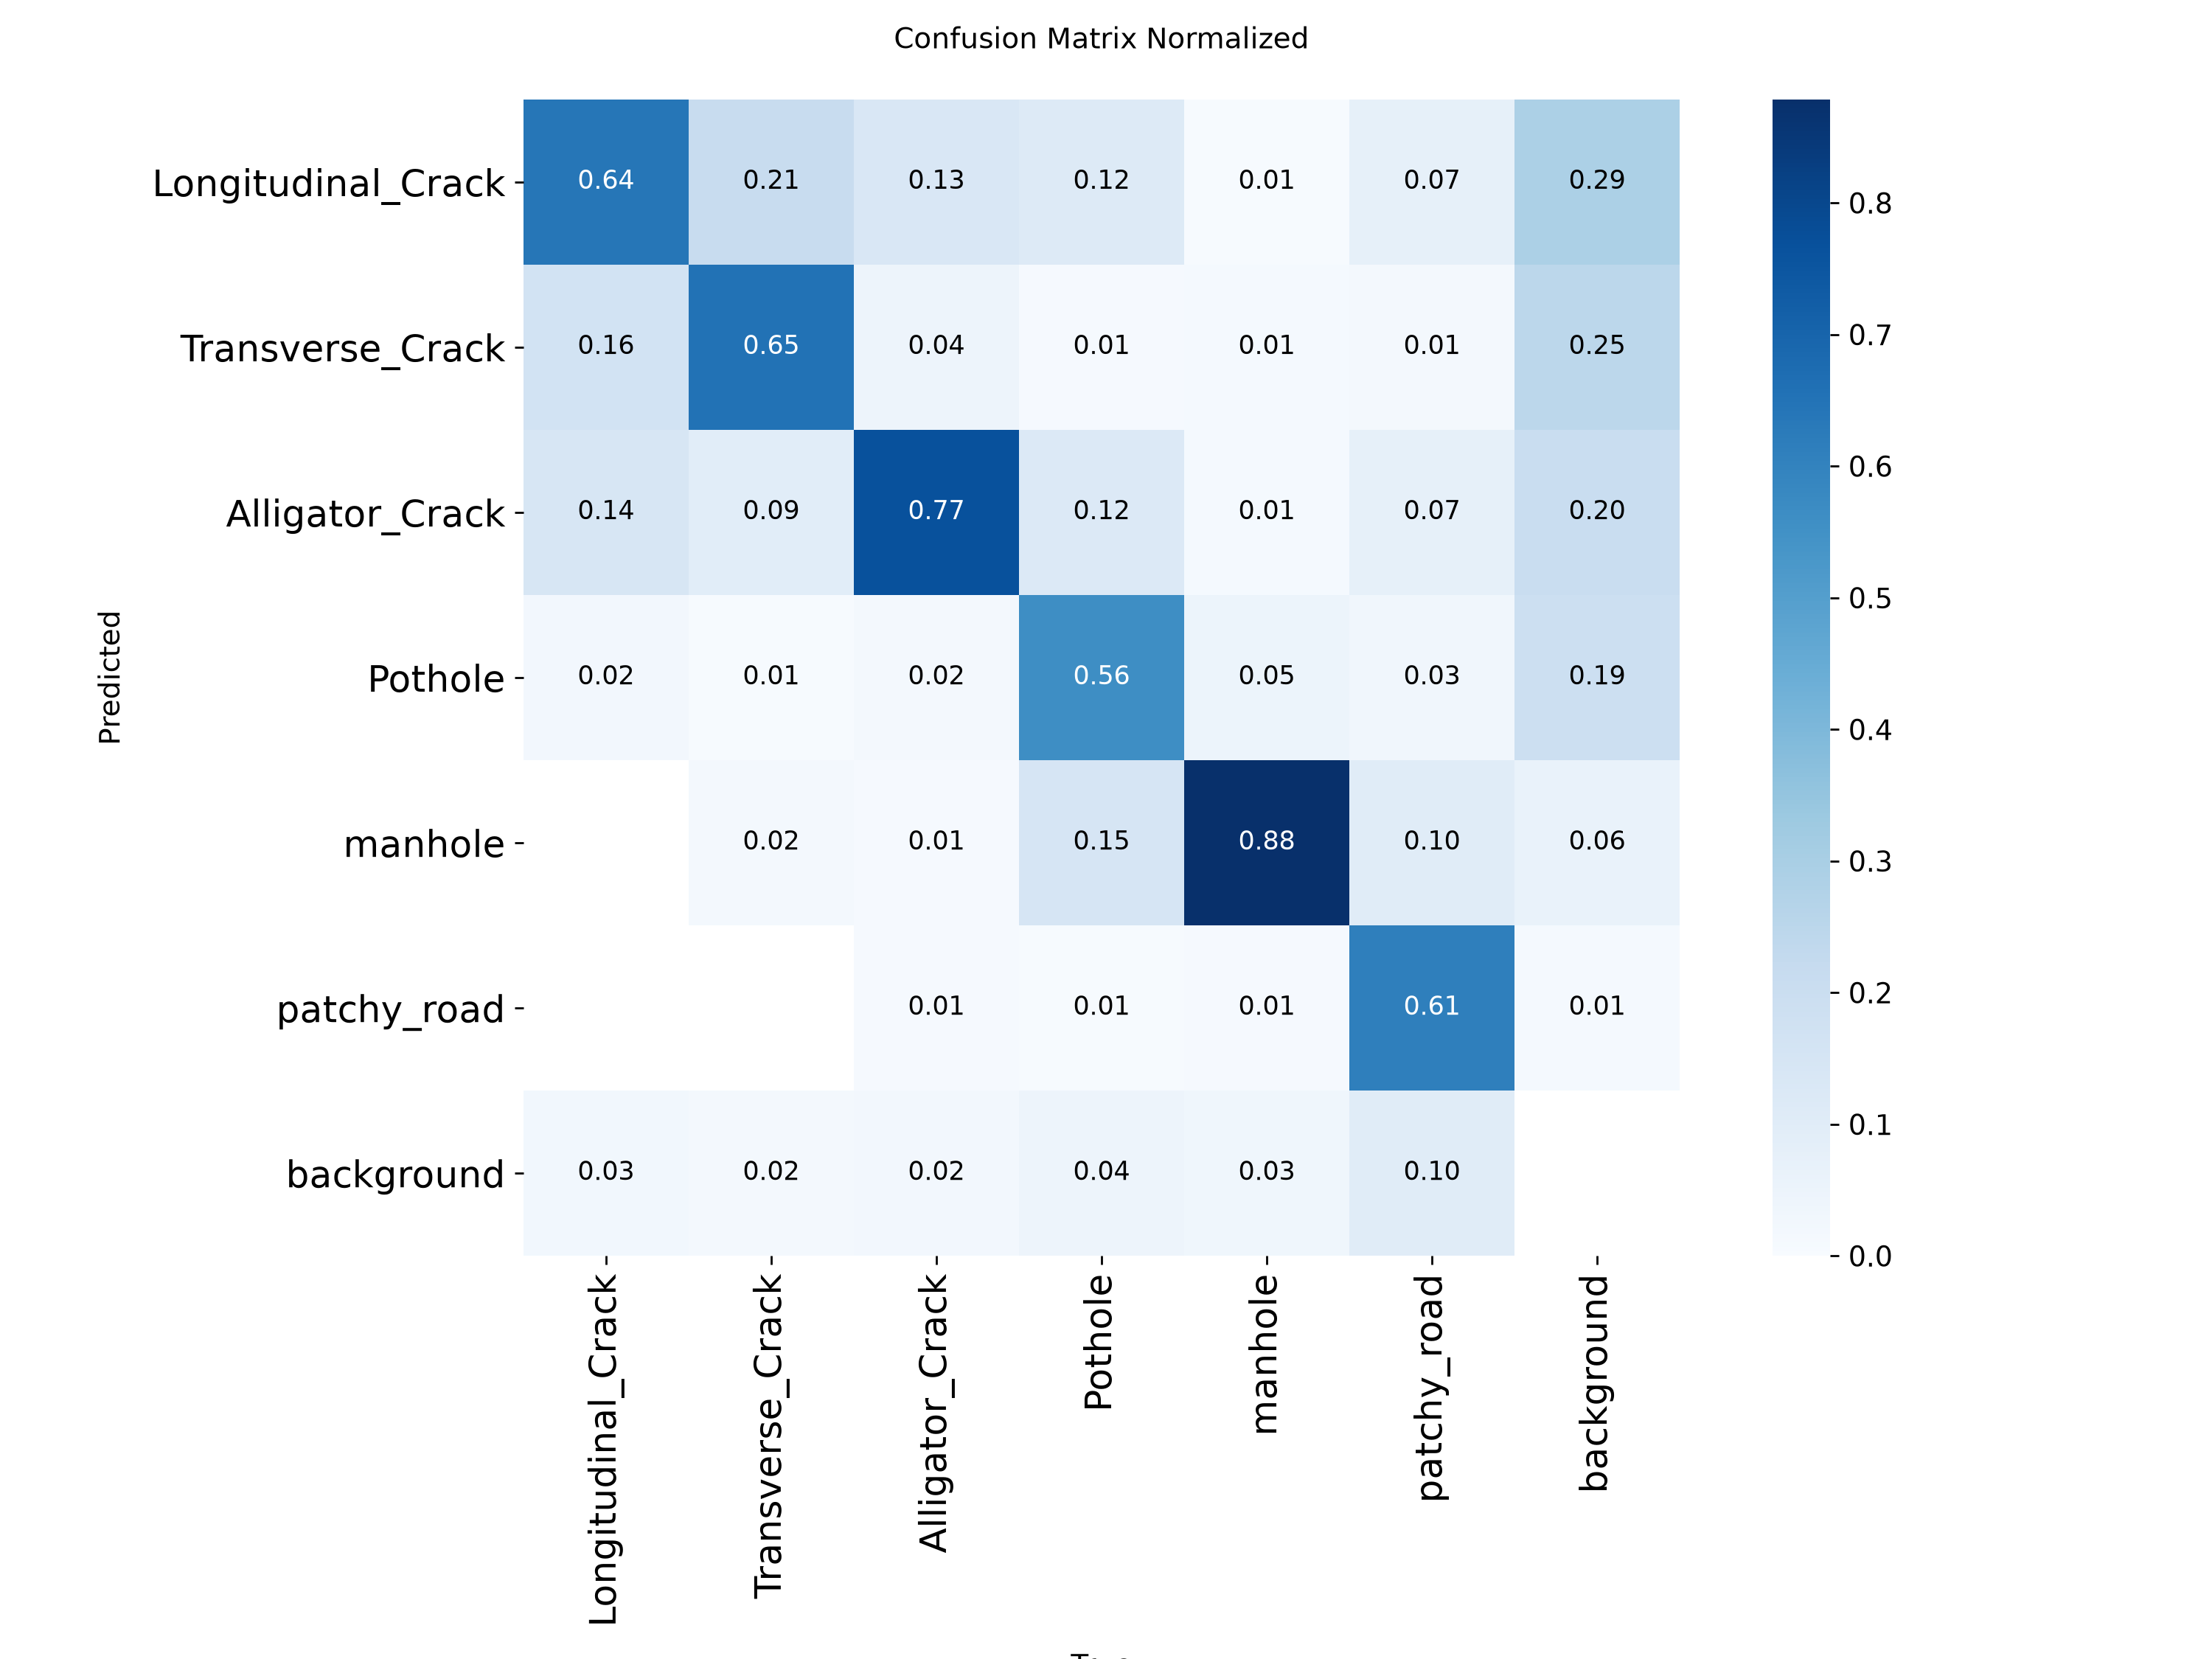

In [14]:
for model_name, run_name in trained_runs:
    print(f"\n{'─'*50}")
    print(f"Model: {model_name}")
    for split in ["val", "test"]:
        eval_subdir = EVAL_DIR / f"{model_name}_{split}"
        for plot_file in [
            "confusion_matrix.png",
            "confusion_matrix_normalized.png",
            "PR_curve.png",
            "F1_curve.png",
        ]:
            plot_path = eval_subdir / plot_file
            if plot_path.exists():
                print(f"  {split} — {plot_file}")
                display(Image(str(plot_path)))

### ***Prediksi Sampel Test per Model***


0: 640x640 2 Transverse_Cracks, 4.4ms
1: 640x640 1 Longitudinal_Crack, 2 Alligator_Cracks, 1 manhole, 4.4ms
2: 640x640 1 Longitudinal_Crack, 1 Transverse_Crack, 1 manhole, 4.4ms
3: 640x640 2 Alligator_Cracks, 1 manhole, 4.4ms
4: 640x640 2 Longitudinal_Cracks, 4.4ms
5: 640x640 1 Pothole, 4.4ms
Speed: 1.2ms preprocess, 4.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local\predictions\yolov8n_class_weight_test_samples
6 labels saved to D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local\predictions\yolov8n_class_weight_test_samples\labels

──────────────────────────────────────────────────
Model: yolov8n_class_weight — prediksi sampel test (PRED_CONF=0.25, PRED_IOU=0.6)


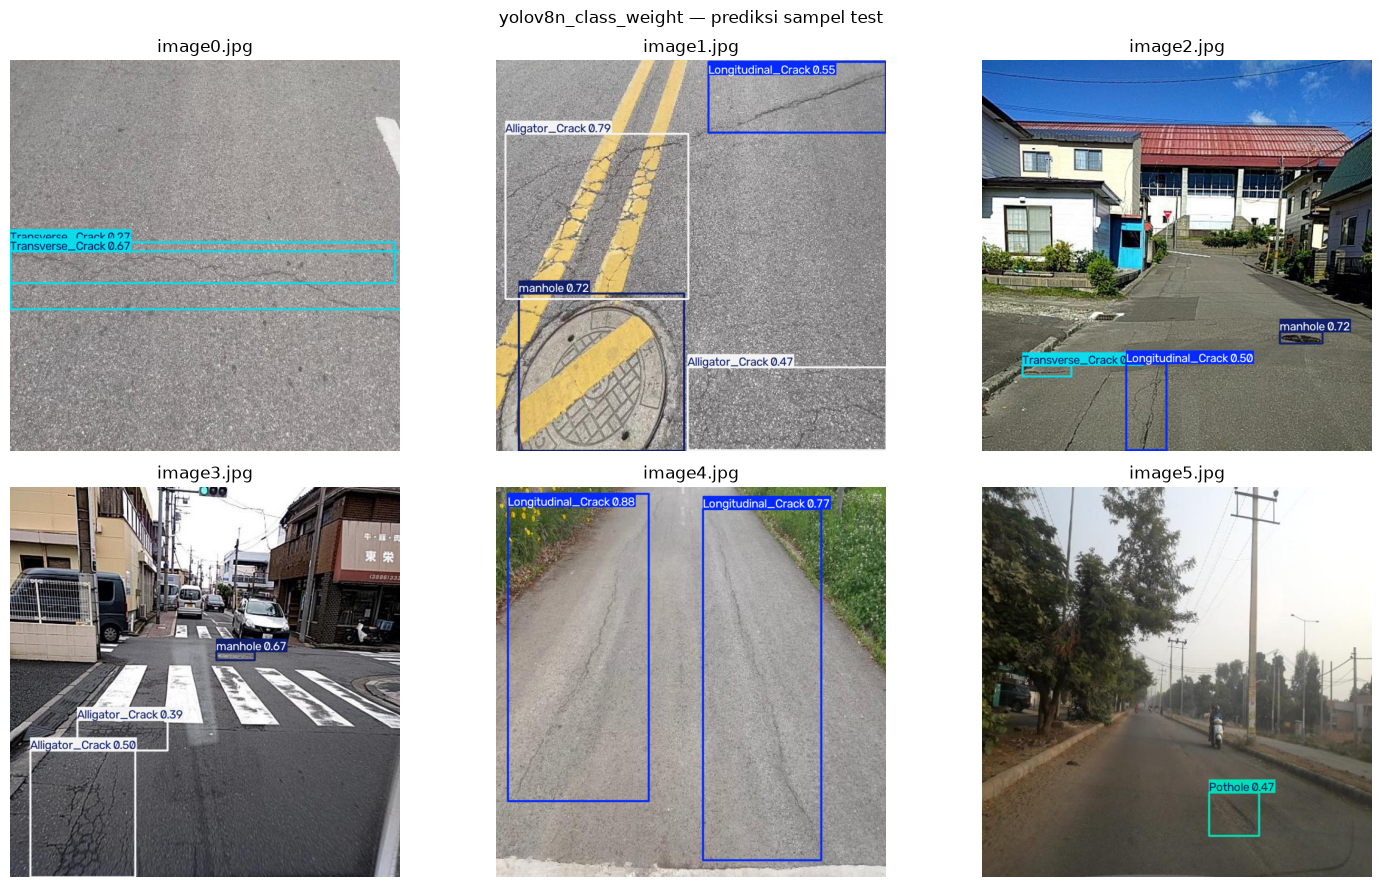


0: 640x640 1 Transverse_Crack, 3.9ms
1: 640x640 1 Longitudinal_Crack, 2 Alligator_Cracks, 1 manhole, 3.9ms
2: 640x640 1 Transverse_Crack, 1 manhole, 3.9ms
3: 640x640 2 Alligator_Cracks, 1 manhole, 3.9ms
4: 640x640 2 Longitudinal_Cracks, 3.9ms
5: 640x640 1 Pothole, 3.9ms
Speed: 1.2ms preprocess, 3.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local\predictions\yolov12n_class_weight_test_samples
6 labels saved to D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_yolov8n_local\predictions\yolov12n_class_weight_test_samples\labels

──────────────────────────────────────────────────
Model: yolov12n_class_weight — prediksi sampel test (PRED_CONF=0.25, PRED_IOU=0.6)


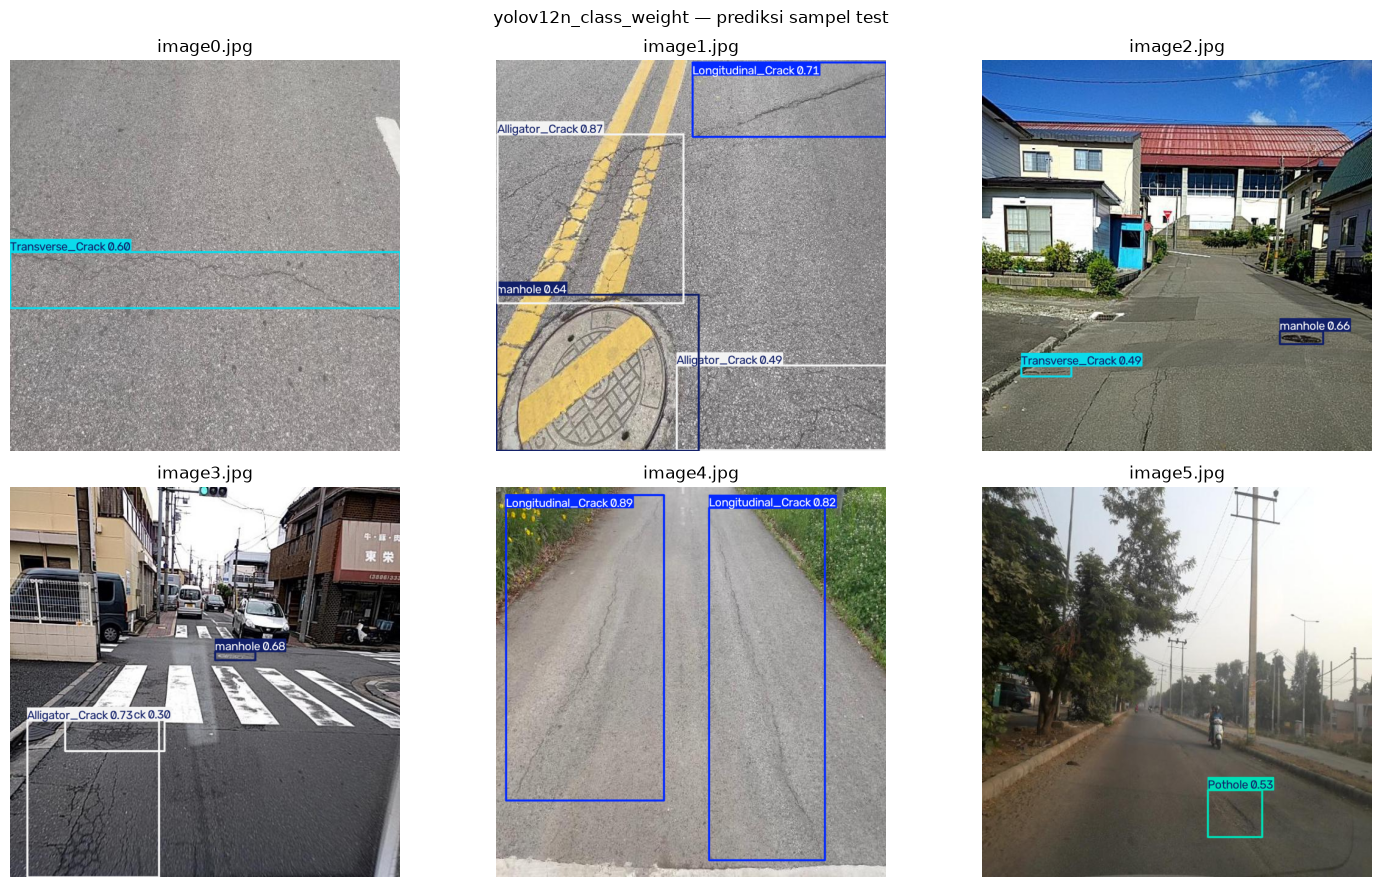

In [15]:
PREDICT_DIR   = OUTPUT_DIR / "predictions"
N_PRED_IMAGES = 6
test_images   = list_images("test")
sample_test   = random.sample(test_images, k=min(N_PRED_IMAGES, len(test_images)))

for model_name, run_name in trained_runs:
    best_weights = PROJECT_DIR / run_name / "weights/best.pt"
    best_model   = YOLO(str(best_weights))

    results = best_model.predict(
        source=[str(p) for p in sample_test],
        imgsz=IMGSZ,
        conf=PRED_CONF,
        iou=PRED_IOU,
        device=DEVICE,
        project=str(PREDICT_DIR),
        name=f"{model_name}_test_samples",
        exist_ok=True,
        save=True,
        save_txt=True,
        save_conf=True,
    )

    print(f"\n{'─'*50}")
    print(f"Model: {model_name} — prediksi sampel test ({PRED_CONF=}, {PRED_IOU=})")
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    for ax, r in zip(axes, results):
        ax.imshow(r.plot()[:, :, ::-1])
        ax.set_title(Path(r.path).name[:45])
        ax.axis("off")
    for ax in axes[len(results):]:
        ax.axis("off")
    plt.suptitle(f"{model_name} — prediksi sampel test")
    plt.tight_layout()
    plt.show()

### ***Confidence Sweep (Opsional)***

In [16]:
RUN_CONFIDENCE_SWEEP = False
CONF_SWEEP = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

if RUN_CONFIDENCE_SWEEP:
    for model_name, run_name in trained_runs:
        best_weights = PROJECT_DIR / run_name / "weights/best.pt"
        best_model   = YOLO(str(best_weights))
        rows = []
        for conf in CONF_SWEEP:
            metrics = best_model.val(
                data=str(local_yaml),
                split="test",
                imgsz=IMGSZ,
                batch=BATCH,
                device=DEVICE,
                workers=WORKERS,
                project=str(EVAL_DIR),
                name=f"{model_name}_conf_{conf:.2f}".replace(".", "p"),
                exist_ok=True,
                plots=False,
                save_json=False,
                conf=conf,
                iou=EVAL_IOU,
                verbose=False,
            )
            rows.append({"model": model_name, "conf": conf, **{k: float(v) for k, v in metrics.results_dict.items()}})
        conf_sweep_df = pd.DataFrame(rows)
        display(conf_sweep_df)
        conf_sweep_df.to_csv(OUTPUT_DIR / f"{model_name}_confidence_sweep_test.csv", index=False)
else:
    print("Confidence sweep dilewati. Set RUN_CONFIDENCE_SWEEP=True jika ingin menjalankan.")

Confidence sweep dilewati. Set RUN_CONFIDENCE_SWEEP=True jika ingin menjalankan.


## ***Template Zero-Shot Bandung***

---

Jika data primer Bandung sudah diberi label YOLO, buat struktur berikut:

```
data/primary_bandung_yolo/
  data.yaml
  test/images/
  test/labels/
```

Lalu isi `PRIMARY_DATA_YAML`. Jika data primer belum berlabel, gunakan mode `predict` untuk inspeksi kualitatif.

In [17]:
PRIMARY_DATA_YAML  = REPO_ROOT / "data/primary_bandung_yolo/data.yaml"
PRIMARY_IMAGES_DIR = REPO_ROOT / "data/primary_bandung_yolo/images"

# Gunakan model terbaik (model pertama di trained_runs) untuk zero-shot.
# Ubah indeks jika ingin model yang berbeda.
if trained_runs:
    zs_model_name, zs_run_name = trained_runs[0]
    zs_weights = PROJECT_DIR / zs_run_name / "weights/best.pt"
    zs_model   = YOLO(str(zs_weights))

    if PRIMARY_DATA_YAML.exists():
        zero_shot_metrics = zs_model.val(
            data=str(PRIMARY_DATA_YAML),
            split="test",
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=WORKERS,
            project=str(EVAL_DIR),
            name=f"{zs_model_name}_zero_shot_bandung",
            exist_ok=True,
            plots=True,
            save_json=True,
            conf=EVAL_CONF,
            iou=EVAL_IOU,
        )
        print(zero_shot_metrics.results_dict)
    else:
        print(f"Belum ada data primer berlabel: {PRIMARY_DATA_YAML}")

    if PRIMARY_IMAGES_DIR.exists():
        bandung_images = sorted([p for p in PRIMARY_IMAGES_DIR.iterdir() if p.suffix.lower() in IMG_EXTS])
        if bandung_images:
            zs_model.predict(
                source=[str(p) for p in bandung_images[:50]],
                imgsz=IMGSZ,
                conf=PRED_CONF,
                iou=PRED_IOU,
                device=DEVICE,
                project=str(PREDICT_DIR),
                name=f"{zs_model_name}_zero_shot_bandung_unlabeled",
                exist_ok=True,
                save=True,
                save_txt=True,
                save_conf=True,
            )
            print(f"Prediksi zero-shot tersimpan di: {PREDICT_DIR / f'{zs_model_name}_zero_shot_bandung_unlabeled'}")
    else:
        print(f"Belum ada folder gambar primer tanpa label: {PRIMARY_IMAGES_DIR}")
else:
    print("trained_runs kosong — jalankan cell training terlebih dahulu.")

Belum ada data primer berlabel: D:\Faaris\Project-TA\road-damage-detection-ta\data\primary_bandung_yolo\data.yaml
Belum ada folder gambar primer tanpa label: D:\Faaris\Project-TA\road-damage-detection-ta\data\primary_bandung_yolo\images


## ***Output Penting untuk Laporan TA***

---

Setelah training dan evaluasi selesai, kumpulkan artefak berikut per model:

**Bobot terlatih**
- `runs/rdd_yolov8n_local/experiments/<model_name>/weights/best.pt`

**Ringkasan metrik**
- `runs/rdd_yolov8n_local/<model_name>_summary.json`
- `runs/rdd_yolov8n_local/<model_name>_f1_summary.csv`
- `runs/rdd_yolov8n_local/<model_name>_val_per_class_metrics.csv`
- `runs/rdd_yolov8n_local/<model_name>_test_per_class_metrics.csv`

**Dataset**
- `runs/rdd_yolov8n_local/dataset_class_distribution.csv`
- `runs/rdd_yolov8n_local/dataset_split_summary.csv`

**Plot evaluasi** (confusion matrix, PR curve, F1 curve)
- `runs/rdd_yolov8n_local/evaluation/<model_name>_val/`
- `runs/rdd_yolov8n_local/evaluation/<model_name>_test/`

**Prediksi sampel**
- `runs/rdd_yolov8n_local/predictions/<model_name>_test_samples/`